In [3]:
!pip -q install mlxtend openpyxl matplotlib seaborn scikit-learn pandas==2.2.2

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
from tabulate import tabulate
from IPython.display import Markdown, display
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from sklearn.mixture import GaussianMixture

SEED = 42
np.random.seed(SEED); random.seed(SEED)
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set(style="whitegrid")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
INPUT_PATH = '/content/drive/MyDrive/HW1_var_5.csv'

def try_read(path: str) -> pd.DataFrame:
    try:
        df = pd.read_excel(path)
        print("Excel:", df.shape)
        return df
    except Exception:
        pass
    encodings = ['utf-8-sig', 'cp1251', 'utf-8']
    seps = [None, ';', ',', '\t']
    decimals = [',', '.']
    for enc in encodings:
        for sep in seps:
            for dec in decimals:
                try:
                    df = pd.read_csv(path, sep=sep, encoding=enc, engine='python', decimal=dec)
                    if df.shape[1] == 1 and ';' in str(df.columns[0]):
                        df = pd.read_csv(path, sep=';', encoding=enc, engine='python', decimal=dec)
                    print(f"CSV: sep={sep}, enc={enc}, dec={dec} ->", df.shape)
                    return df
                except Exception:
                    continue
    raise RuntimeError("Не удалось прочитать файл :(")

df_original = try_read(INPUT_PATH)
df_original.columns = [str(c).strip() for c in df_original.columns]

if 'ID' in df_original.columns:
    if df_original['ID'].isna().any():
        df_original['ID'] = df_original['ID'].astype(str).str.strip()
    else:
        df_original['ID'] = pd.to_numeric(df_original['ID'], errors='coerce').astype('Int64')

display(df_original.head(3))


CSV: sep=None, enc=utf-8-sig, dec=, -> (10243, 44)


,Номер варианта,ID,INCOME_BASE_TYPE,CREDIT_PURPOSE,INSURANCE_FLAG,DTI,SEX,FULL_AGE_CHILD_NUMBER,DEPENDANT_NUMBER,EDUCATION,EMPL_TYPE,EMPL_SIZE,BANKACCOUNT_FLAG,Period_at_work,age,EMPL_PROPERTY,EMPL_FORM,FAMILY_STATUS,max90days,max60days,max30days,max21days,max14days,avg_num_delay,if_zalog,num_AccountActive180,num_AccountActive90,num_AccountActive60,Active_to_All_prc,numAccountActiveAll,numAccountClosed,sum_of_paym_months,all_credits,Active_not_cc,own_closed,min_MnthAfterLoan,max_MnthAfterLoan,dlq_exist,thirty_in_a_year,sixty_in_a_year,ninety_in_a_year,thirty_vintage,sixty_vintage,ninety_vintage
0,5,1000005,Поступление зарплаты на счет,Покупка недвижимости/ строительство,1,0.26,мужской,0,0,среднее,рабочий,>=200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5,1000025,Поступление зарплаты на счет,Покупка автомобиля,1,0.45,мужской,1,0,высшее,менеджер среднего звена,>250,1.0,54.0,29.0,Производство,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5,1000045,2НДФЛ,Ремонт,1,0.49,мужской,0,0,высшее,менеджер среднего звена,>250,0.0,29.0,35.0,Информационные технологии,ООО,холост / не замужем,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,61.0,1.0,0.0,0.0,66.0,66.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Предварительный анализ данных

In [6]:
df = df_original.copy()
print("Столбцы:")
for c in df.columns: print('-', c)

Столбцы:
- Номер варианта
- ID
- INCOME_BASE_TYPE
- CREDIT_PURPOSE
- INSURANCE_FLAG
- DTI
- SEX
- FULL_AGE_CHILD_NUMBER
- DEPENDANT_NUMBER
- EDUCATION
- EMPL_TYPE
- EMPL_SIZE
- BANKACCOUNT_FLAG
- Period_at_work
- age
- EMPL_PROPERTY
- EMPL_FORM
- FAMILY_STATUS
- max90days
- max60days
- max30days
- max21days
- max14days
- avg_num_delay
- if_zalog
- num_AccountActive180
- num_AccountActive90
- num_AccountActive60
- Active_to_All_prc
- numAccountActiveAll
- numAccountClosed
- sum_of_paym_months
- all_credits
- Active_not_cc
- own_closed
- min_MnthAfterLoan
- max_MnthAfterLoan
- dlq_exist
- thirty_in_a_year
- sixty_in_a_year
- ninety_in_a_year
- thirty_vintage
- sixty_vintage
- ninety_vintage


Унификация ключевых названий

In [7]:
df.columns = [c.strip() for c in df.columns]
colmap = {}
for c in df.columns:
    lc = c.lower()
    if lc in ['order_id','заказ','номер заказа']: colmap[c] = 'Order_ID'
    elif lc in ['email','email_new']: colmap[c] = 'Email_new'
    elif 'phone' in lc or 'тел' in lc: colmap[c] = 'Phone_new'
    elif 'orderdate' in lc or 'дата заказа' in lc: colmap[c] = 'OrderDate'
    elif 'ordertime' in lc or 'время заказа' in lc: colmap[c] = 'OrderTime'
    elif 'ordermonth' in lc or 'месяц' in lc: colmap[c] = 'OrderMonth'
    elif 'changedate' in lc: colmap[c] = 'ChangeDate'
    elif 'deliverydate' in lc: colmap[c] = 'DeliveryDate'
    elif 'paymentdate' in lc: colmap[c] = 'PaymentDate'
    elif 'status_id' in lc: colmap[c] = 'Status_ID'
    elif 'status' in lc: colmap[c] = 'Status'
    elif 'cancelreason' in lc or 'причина отмены' in lc: colmap[c] = 'CancelReason'
    elif 'actions' in lc: colmap[c] = 'Actions'
    elif 'deliverytype' in lc: colmap[c] = 'DeliveryType'
    elif 'paymenttype' in lc or 'способ оплаты' in lc: colmap[c] = 'PaymentType'
    elif 'region' in lc or 'город' in lc or 'область' in lc: colmap[c] = 'Region'
    elif 'area' in lc: colmap[c] = 'Area'
    elif 'store_id' in lc: colmap[c] = 'Store_ID'
    elif 'fullsum' in lc or 'сумма чека' in lc: colmap[c] = 'FullSum'
    elif lc == 'discount': colmap[c] = 'Discount'
    elif 'im_rozn_sum' in lc: colmap[c] = 'IM_Rozn_Sum'
    elif 'row_id' in lc: colmap[c] = 'Row_ID'
    elif 'articul' in lc: colmap[c] = 'Articul'
    elif 'nom_name' in lc or 'наименование' in lc: colmap[c] = 'Nom_Name'
    elif 'nomgroup' in lc or 'группа' == lc: colmap[c] = 'NomGroup'
    elif 'quant' in lc or 'quantity' in lc or 'кол-во' in lc: colmap[c] = 'Quant'
    elif 'rowprice' in lc or 'цена' in lc: colmap[c] = 'RowPrice'
    elif 'rowdiscount' in lc: colmap[c] = 'RowDiscount'
    elif 'rowsum' in lc: colmap[c] = 'RowSum'
    elif lc == 'brand': colmap[c] = 'Brand'
    elif lc == 'tn': colmap[c] = 'TN'
    elif lc == 'tk': colmap[c] = 'TK'
    elif 'nomfullpath' in lc: colmap[c] = 'NomFullPath'
    elif lc == 'week': colmap[c] = 'Week'
    elif lc == 'nom_id': colmap[c] = 'Nom_ID'
    elif 'source' in lc or 'канал' in lc: colmap[c] = 'Source'

In [8]:
df = df.rename(columns=colmap)

In [9]:
if 'EMPL_SIZE' in df.columns:
    df['EMPL_SIZE'] = (df['EMPL_SIZE'].astype(str)
                       .str.replace(r'>=\s*200', '>200', regex=True)
                       .str.replace(r'>=\s*250', '>250', regex=True)
                       .str.replace(r'\s+', ' ', regex=True)
                       .str.strip())

Функция аудита

In [10]:
def columnValues(s: pd.Series):
    zeros = int((s == 0).sum()) if pd.api.types.is_numeric_dtype(s) else 0
    return [s.nunique(dropna=True), zeros, int(s.isna().sum()),
            round(s.isna().mean()*100, 1), s.dtype]

audit_rows = []
for col in df.columns:
    audit_rows.append([col] + columnValues(df[col]))

print(tabulate(audit_rows,
               headers=['Column','Unique','Zeros','NaNs','%NaN','dtype'],
               tablefmt='orgtbl'))

| Column                |   Unique |   Zeros |   NaNs |   %NaN | dtype   |
|-----------------------+----------+---------+--------+--------+---------|
| Номер варианта        |        1 |       0 |      0 |    0   | int64   |
| ID                    |    10243 |       0 |      0 |    0   | Int64   |
| INCOME_BASE_TYPE      |        4 |       0 |     57 |    0.6 | object  |
| CREDIT_PURPOSE        |       10 |       0 |      0 |    0   | object  |
| INSURANCE_FLAG        |        2 |    4104 |      0 |    0   | int64   |
| DTI                   |       61 |       1 |    122 |    1.2 | float64 |
| SEX                   |        2 |       0 |      0 |    0   | object  |
| FULL_AGE_CHILD_NUMBER |        7 |    6154 |      0 |    0   | int64   |
| DEPENDANT_NUMBER      |        3 |   10214 |      0 |    0   | int64   |
| EDUCATION             |        9 |       0 |      0 |    0   | object  |
| EMPL_TYPE             |        9 |       0 |      9 |    0.1 | object  |
| EMPL_SIZE             |

# Анализ признаков и типичного клиента

In [11]:
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in ['ID','Номер варианта']]
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print('Числовые признаки:', num_cols)
print('Категориальные признаки:', cat_cols)

display(df.describe(include='all').T.head(20))

Числовые признаки: ['INSURANCE_FLAG', 'DTI', 'FULL_AGE_CHILD_NUMBER', 'DEPENDANT_NUMBER', 'BANKACCOUNT_FLAG', 'Period_at_work', 'age', 'max90days', 'max60days', 'max30days', 'max21days', 'max14days', 'avg_num_delay', 'if_zalog', 'num_AccountActive180', 'num_AccountActive90', 'num_AccountActive60', 'Active_to_All_prc', 'numAccountActiveAll', 'numAccountClosed', 'sum_of_paym_months', 'all_credits', 'Active_not_cc', 'own_closed', 'min_MnthAfterLoan', 'max_MnthAfterLoan', 'dlq_exist', 'thirty_in_a_year', 'sixty_in_a_year', 'ninety_in_a_year', 'thirty_vintage', 'sixty_vintage', 'ninety_vintage']
Категориальные признаки: ['INCOME_BASE_TYPE', 'CREDIT_PURPOSE', 'SEX', 'EDUCATION', 'EMPL_TYPE', 'EMPL_SIZE', 'EMPL_PROPERTY', 'EMPL_FORM', 'Status']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Номер варианта,10243.0,NaN,NaN,NaN,5.0,0.0,5.0,5.0,5.0,5.0,5.0
ID,10243.0,<NA>,<NA>,<NA>,1102425.0,59140.874754,1000005.0,1051215.0,1102425.0,1153635.0,1204845.0
INCOME_BASE_TYPE,10186,4,2НДФЛ,3358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CREDIT_PURPOSE,10243,10,Ремонт,5623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INSURANCE_FLAG,10243.0,NaN,NaN,NaN,0.599336,0.490057,0.0,0.0,1.0,1.0,1.0
DTI,10121.0,NaN,NaN,NaN,0.385248,0.135915,0.0,0.28,0.4,0.49,0.6
SEX,10243,2,мужской,5652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FULL_AGE_CHILD_NUMBER,10243.0,NaN,NaN,NaN,0.55433,0.785071,0.0,0.0,0.0,1.0,14.0
DEPENDANT_NUMBER,10243.0,NaN,NaN,NaN,0.00371,0.073851,0.0,0.0,0.0,0.0,2.0
EDUCATION,10243,9,высшее,5818,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (9, 5.5), "axes.titlesize": 14, "axes.labelsize": 12})

def md(text: str):
    display(Markdown(text))

def explain(why: str, what: str, action: str):
    md(f"**Почему этот график релевантен?** {why}  \n"
       f"**Что видно?** {what}  \n"
       f"**Что делаем дальше?** {action}\n\n---")

Корреляционная матрица

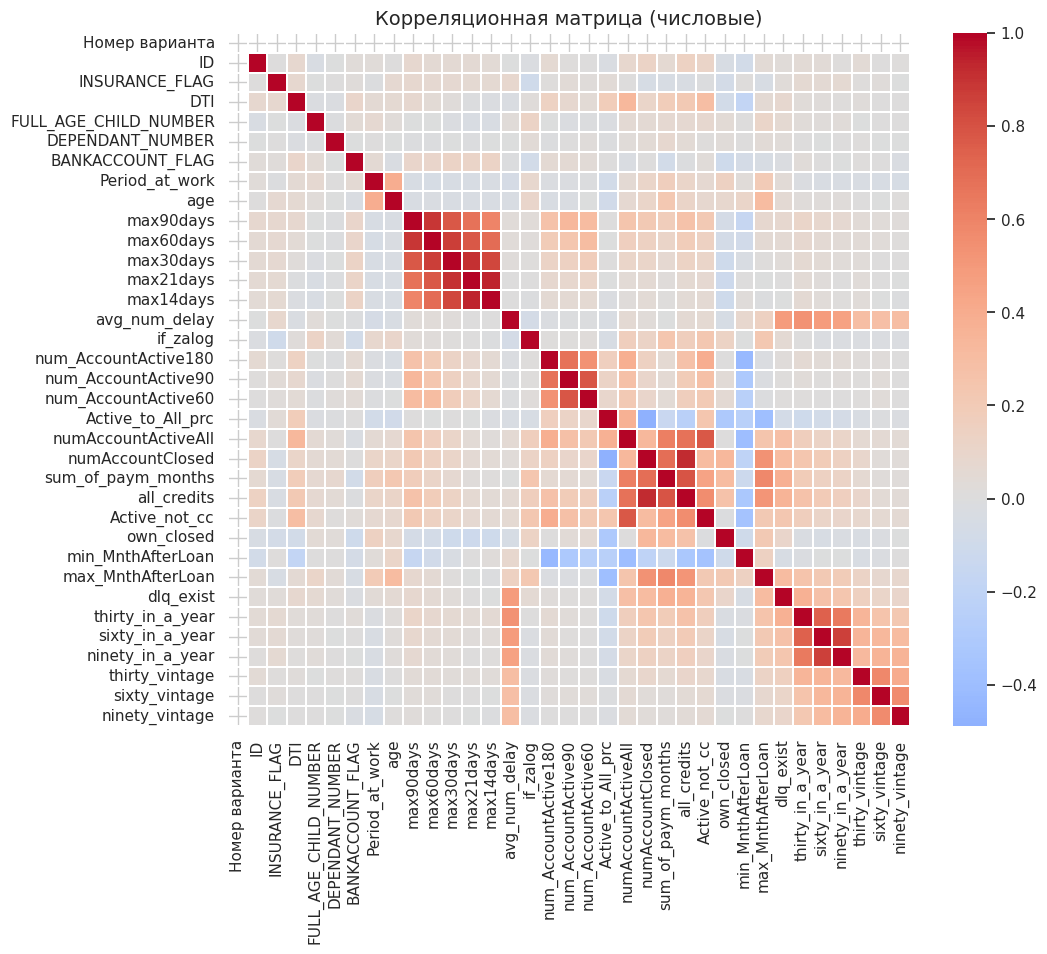

**Почему этот график релевантен?** Корреляции показывают дублирование информации → влияют на масштабирование и центры кластеров.  
**Что видно?** Нашли сильные пары: max60days–max90days (r=0.89), max30days–max60days (r=0.87), max21days–max30days (r=0.91), max14days–max30days (r=0.84), max14days–max21days (r=0.94), all_credits–numAccountClosed (r=0.92), ninety_in_a_year–sixty_in_a_year (r=0.86)  
**Что делаем дальше?** На этапе сегментации используем стандартизацию и PCA (уменьшит эффект мультиколлинеарности).

---

In [13]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) >= 2:
    corr = df[num_cols].corr(method='pearson')
    plt.figure(figsize=(11, 9))
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=.2)
    plt.title("Корреляционная матрица (числовые)")
    plt.show()

    high_pairs = (
        corr.stack().reset_index()
        .rename(columns={'level_0':'f1','level_1':'f2',0:'corr'})
    )
    high_pairs = high_pairs[(high_pairs['f1']<high_pairs['f2']) & (high_pairs['corr'].abs()>=0.8)]
    what_corr = "Нашли сильные пары: " + (", ".join([f"{a}–{b} (r={r:.2f})" for a,b,r in high_pairs.values])
                                          if not high_pairs.empty else "нет пар с |r|≥0.8")
    explain(
        "Корреляции показывают дублирование информации → влияют на масштабирование и центры кластеров.",
        what_corr,
        "На этапе сегментации используем стандартизацию и PCA (уменьшит эффект мультиколлинеарности)."
    )

Функции для графиков с пояснениями

In [14]:
def plot_num(col, bins=30, ref_lines=None):
    """Гистограмма + компактный boxplot и пояснение для числового признака."""
    if col not in df.columns:
        print(f"[skip] {col} нет в df");
        return
    s = pd.to_numeric(df[col], errors='coerce').dropna()
    if s.empty:
        print(f"[skip] {col} пустой");
        return

    q1, q2, q3 = s.quantile([.25,.5,.75])
    s_plot = s.clip(s.quantile(.01), s.quantile(.99))
    fig = plt.figure(constrained_layout=True, figsize=(9,5.8))
    gs  = fig.add_gridspec(nrows=5, ncols=1, height_ratios=[4, .15, 1.2, .15, .1])
    axh = fig.add_subplot(gs[0,0])
    axb = fig.add_subplot(gs[2,0])
    sns.histplot(s_plot, bins=bins, kde=True, ax=axh)
    axh.set_title(f"Распределение — {col}")
    axh.set_xlabel(col); axh.set_ylabel("Частота")
    if ref_lines:
        for v in ref_lines:
            axh.axvline(v, ls='--')

    sns.boxplot(y=s, ax=axb, fliersize=2, width=0.35)
    axb.set_title(f"Boxplot — {col}")
    plt.show()

    why = f"Понимаем форму распределения {col}, выбросы и типичные уровни (Q1/Med/Q3) перед стандартизацией и кластеризацией."
    what = f"Med≈{q2:.3g}, Q1≈{q1:.3g}, Q3≈{q3:.3g}; асимметрия={s.skew():.2f}." + (" Проставлены референс-линии." if ref_lines else "")
    action = "Выбросы не удаляем слепо — их обработает IsolationForest; сильную асимметрию смягчит стандартизация/PCA."
    explain(why, what, action)

def plot_cat(col, top=15):
    """Barplot частот категориального признака с подписями % и пояснением."""
    if col not in df.columns:
        print(f"[skip] {col} нет в df");
        return
    s = df[col].astype(str).str.strip()
    vc = s.value_counts().head(top)
    if vc.empty:
        print(f"[skip] {col} пустой");
        return

    total = s.shape[0]
    ax = sns.barplot(x=vc.values, y=vc.index)
    ax.set_title(f"Распределение: {col}")
    ax.set_xlabel("Количество"); ax.set_ylabel(col)
    for i,(v,k) in enumerate(zip(vc.values, vc.index)):
        ax.text(v*1.01, i, f"{v/total:.1%}")
    plt.tight_layout(); plt.show()

    mode = s.mode().iloc[0] if not s.mode().empty else "—"
    why = "Частоты категорий нужны для one-hot кодирования и портрета «типичного клиента»."
    what = f"Топ категория: **{mode}** ({vc.iloc[0]/total:.1%}). Всего уникальных={s.nunique()}."
    action = "Редкие уровни можно укрупнить (если сильно разрежено) — это упростит интерпретацию сегментов."
    explain(why, what, action)

Числовые графики and Категориальные графики

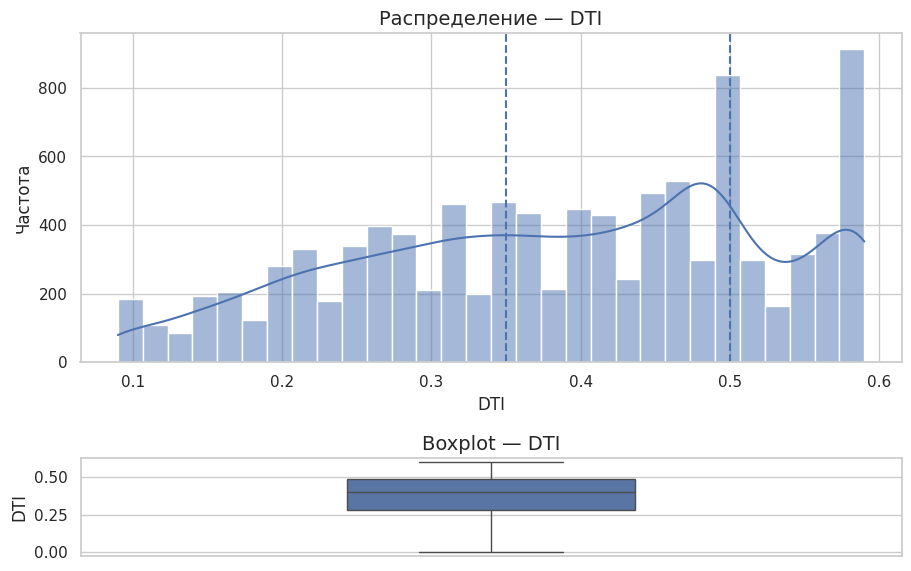

**Почему этот график релевантен?** Понимаем форму распределения DTI, выбросы и типичные уровни (Q1/Med/Q3) перед стандартизацией и кластеризацией.  
**Что видно?** Med≈0.4, Q1≈0.28, Q3≈0.49; асимметрия=-0.29. Проставлены референс-линии.  
**Что делаем дальше?** Выбросы не удаляем слепо — их обработает IsolationForest; сильную асимметрию смягчит стандартизация/PCA.

---

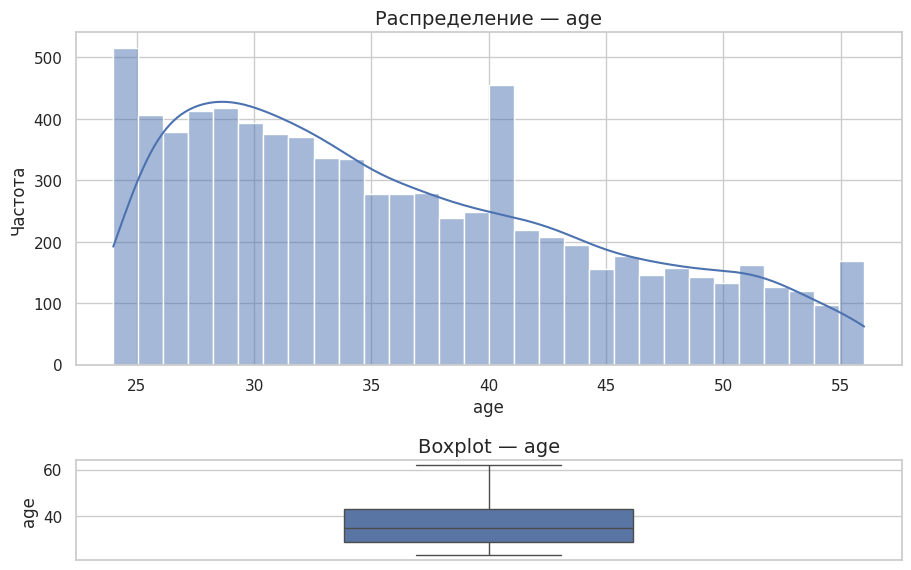

**Почему этот график релевантен?** Понимаем форму распределения age, выбросы и типичные уровни (Q1/Med/Q3) перед стандартизацией и кластеризацией.  
**Что видно?** Med≈35, Q1≈29, Q3≈43; асимметрия=0.55.  
**Что делаем дальше?** Выбросы не удаляем слепо — их обработает IsolationForest; сильную асимметрию смягчит стандартизация/PCA.

---

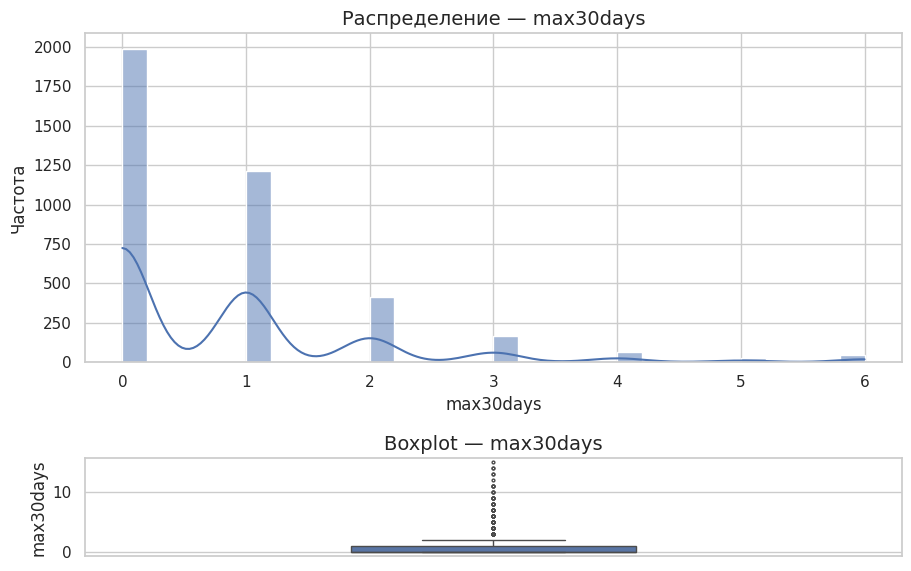

**Почему этот график релевантен?** Понимаем форму распределения max30days, выбросы и типичные уровни (Q1/Med/Q3) перед стандартизацией и кластеризацией.  
**Что видно?** Med≈0, Q1≈0, Q3≈1; асимметрия=3.61.  
**Что делаем дальше?** Выбросы не удаляем слепо — их обработает IsolationForest; сильную асимметрию смягчит стандартизация/PCA.

---

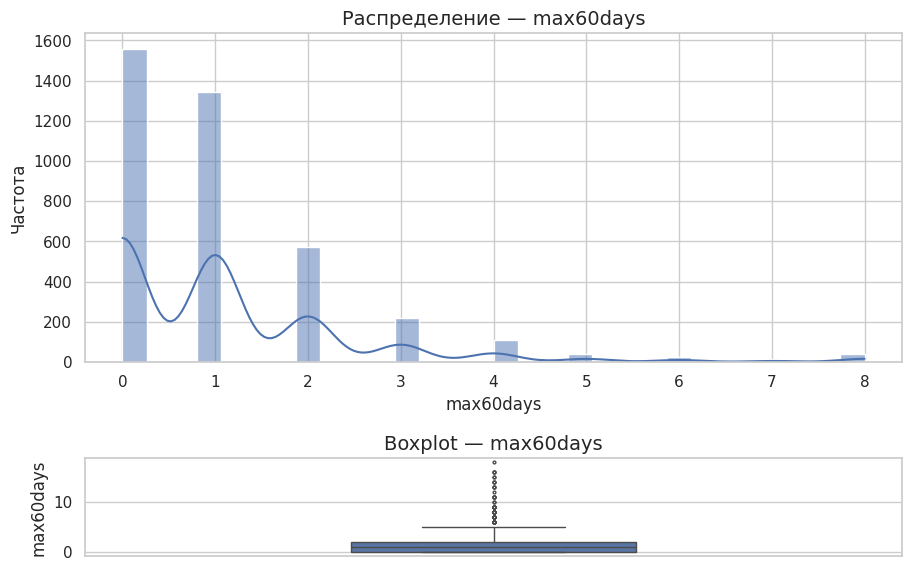

**Почему этот график релевантен?** Понимаем форму распределения max60days, выбросы и типичные уровни (Q1/Med/Q3) перед стандартизацией и кластеризацией.  
**Что видно?** Med≈1, Q1≈0, Q3≈2; асимметрия=3.61.  
**Что делаем дальше?** Выбросы не удаляем слепо — их обработает IsolationForest; сильную асимметрию смягчит стандартизация/PCA.

---

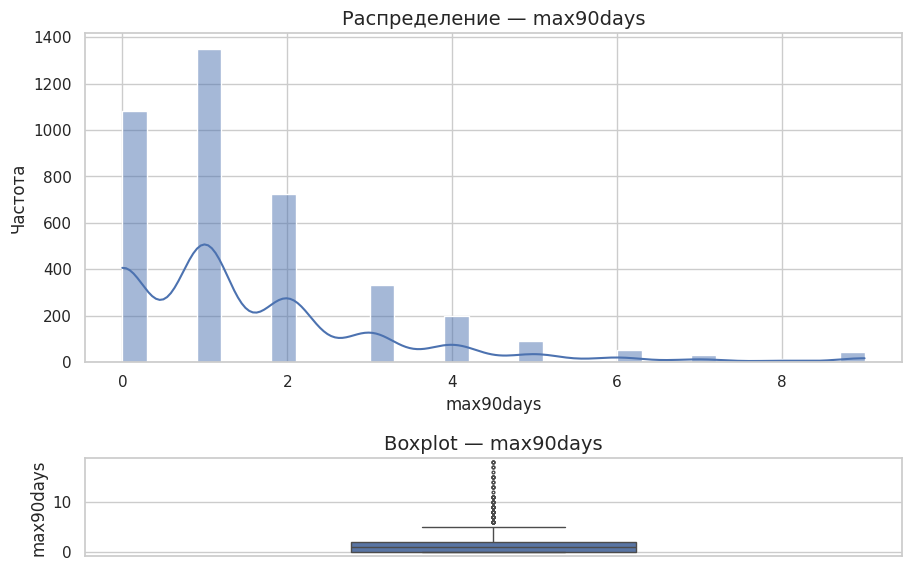

**Почему этот график релевантен?** Понимаем форму распределения max90days, выбросы и типичные уровни (Q1/Med/Q3) перед стандартизацией и кластеризацией.  
**Что видно?** Med≈1, Q1≈0, Q3≈2; асимметрия=3.00.  
**Что делаем дальше?** Выбросы не удаляем слепо — их обработает IsolationForest; сильную асимметрию смягчит стандартизация/PCA.

---

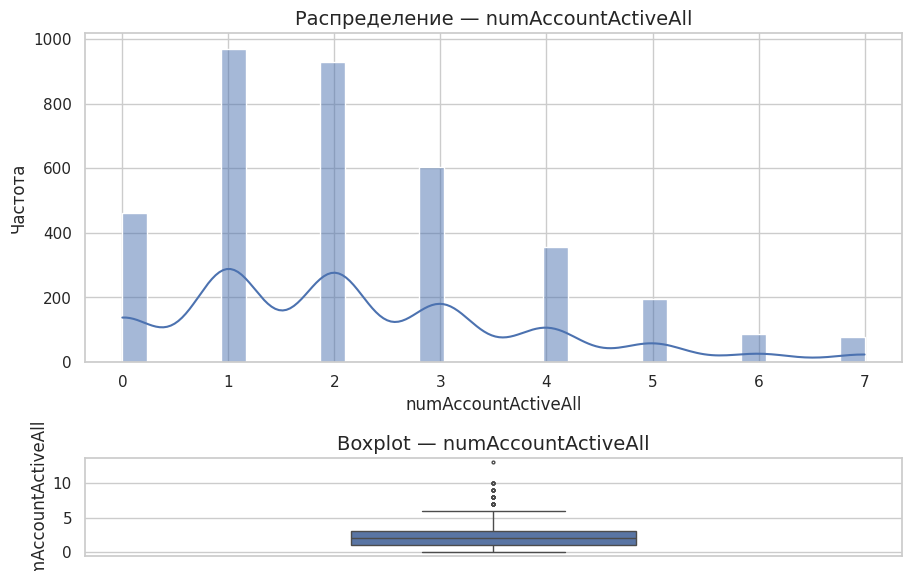

**Почему этот график релевантен?** Понимаем форму распределения numAccountActiveAll, выбросы и типичные уровни (Q1/Med/Q3) перед стандартизацией и кластеризацией.  
**Что видно?** Med≈2, Q1≈1, Q3≈3; асимметрия=1.07.  
**Что делаем дальше?** Выбросы не удаляем слепо — их обработает IsolationForest; сильную асимметрию смягчит стандартизация/PCA.

---

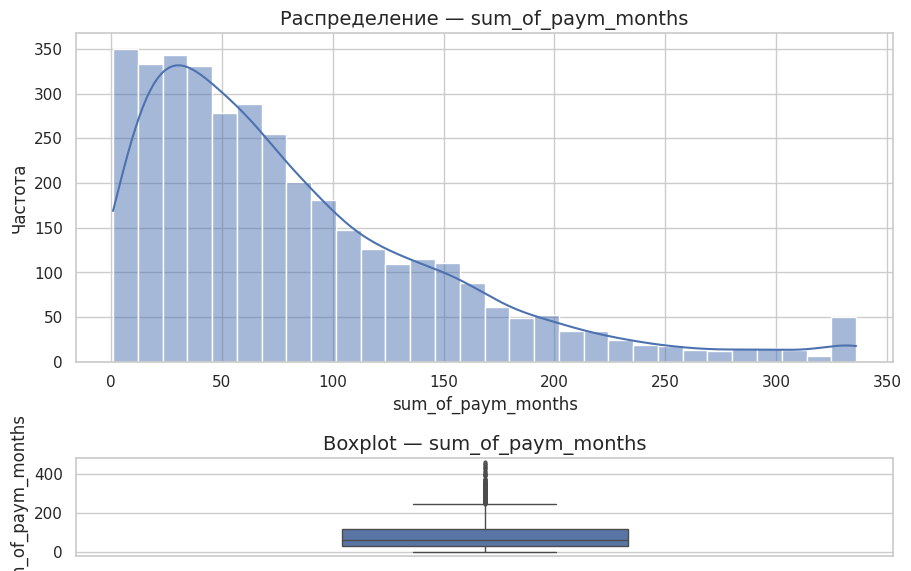

**Почему этот график релевантен?** Понимаем форму распределения sum_of_paym_months, выбросы и типичные уровни (Q1/Med/Q3) перед стандартизацией и кластеризацией.  
**Что видно?** Med≈64, Q1≈31, Q3≈117; асимметрия=1.58.  
**Что делаем дальше?** Выбросы не удаляем слепо — их обработает IsolationForest; сильную асимметрию смягчит стандартизация/PCA.

---

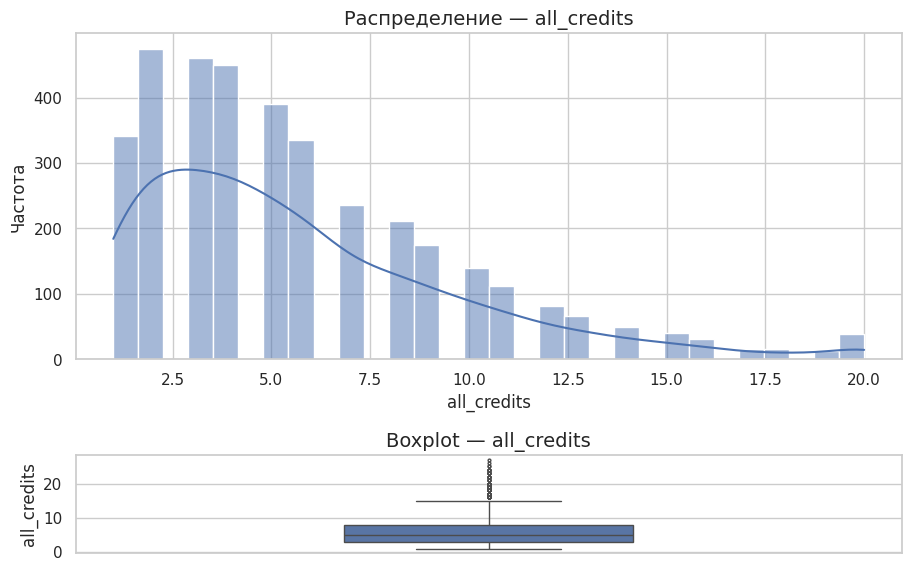

**Почему этот график релевантен?** Понимаем форму распределения all_credits, выбросы и типичные уровни (Q1/Med/Q3) перед стандартизацией и кластеризацией.  
**Что видно?** Med≈5, Q1≈3, Q3≈8; асимметрия=1.38.  
**Что делаем дальше?** Выбросы не удаляем слепо — их обработает IsolationForest; сильную асимметрию смягчит стандартизация/PCA.

---

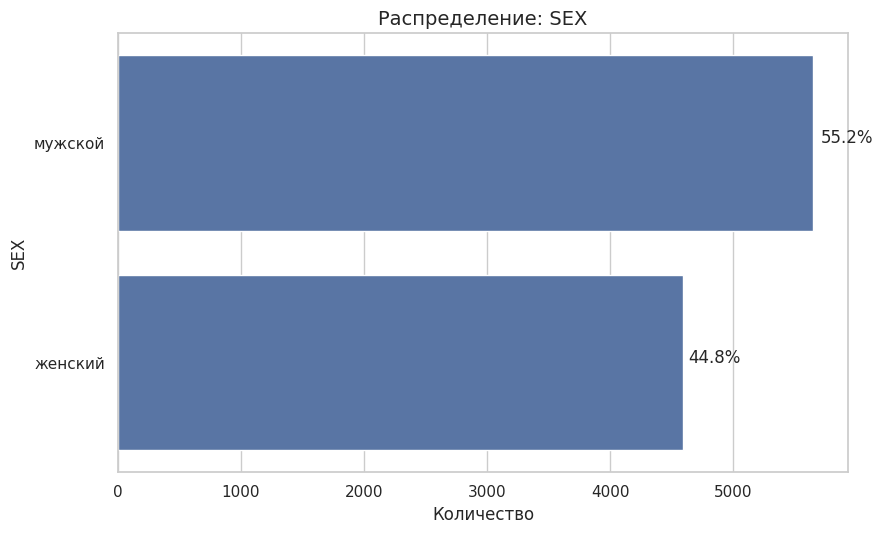

**Почему этот график релевантен?** Частоты категорий нужны для one-hot кодирования и портрета «типичного клиента».  
**Что видно?** Топ категория: **мужской** (55.2%). Всего уникальных=2.  
**Что делаем дальше?** Редкие уровни можно укрупнить (если сильно разрежено) — это упростит интерпретацию сегментов.

---

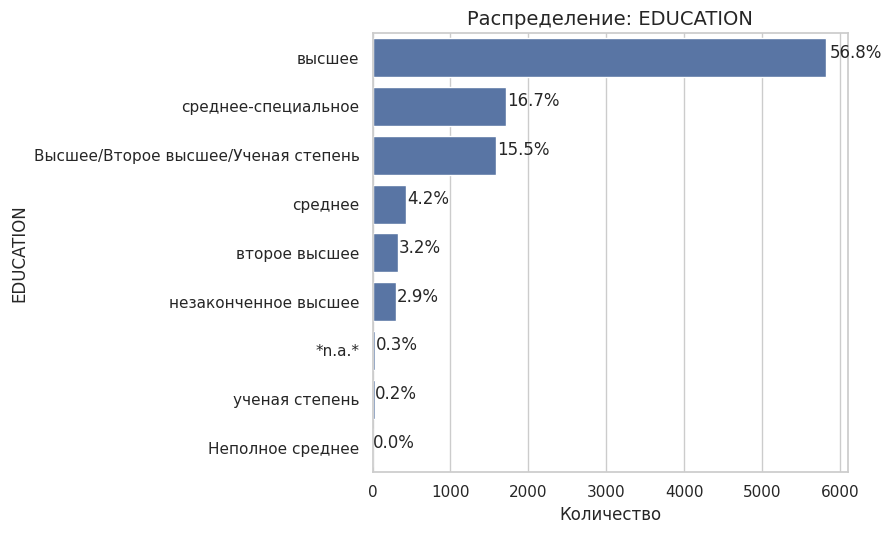

**Почему этот график релевантен?** Частоты категорий нужны для one-hot кодирования и портрета «типичного клиента».  
**Что видно?** Топ категория: **высшее** (56.8%). Всего уникальных=9.  
**Что делаем дальше?** Редкие уровни можно укрупнить (если сильно разрежено) — это упростит интерпретацию сегментов.

---

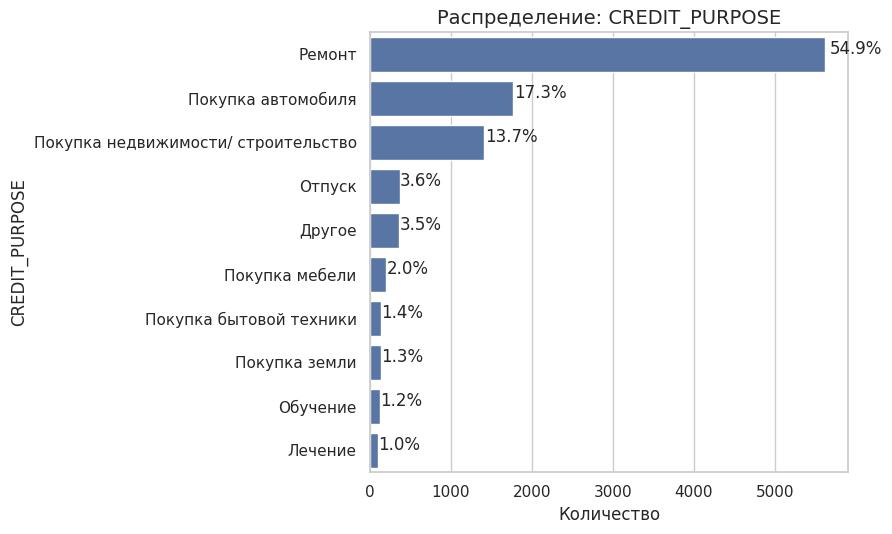

**Почему этот график релевантен?** Частоты категорий нужны для one-hot кодирования и портрета «типичного клиента».  
**Что видно?** Топ категория: **Ремонт** (54.9%). Всего уникальных=10.  
**Что делаем дальше?** Редкие уровни можно укрупнить (если сильно разрежено) — это упростит интерпретацию сегментов.

---

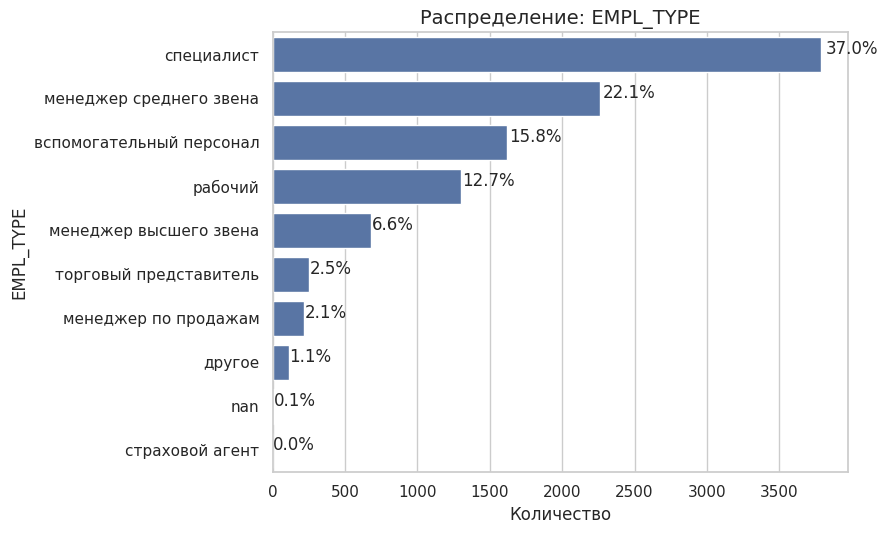

**Почему этот график релевантен?** Частоты категорий нужны для one-hot кодирования и портрета «типичного клиента».  
**Что видно?** Топ категория: **специалист** (37.0%). Всего уникальных=10.  
**Что делаем дальше?** Редкие уровни можно укрупнить (если сильно разрежено) — это упростит интерпретацию сегментов.

---

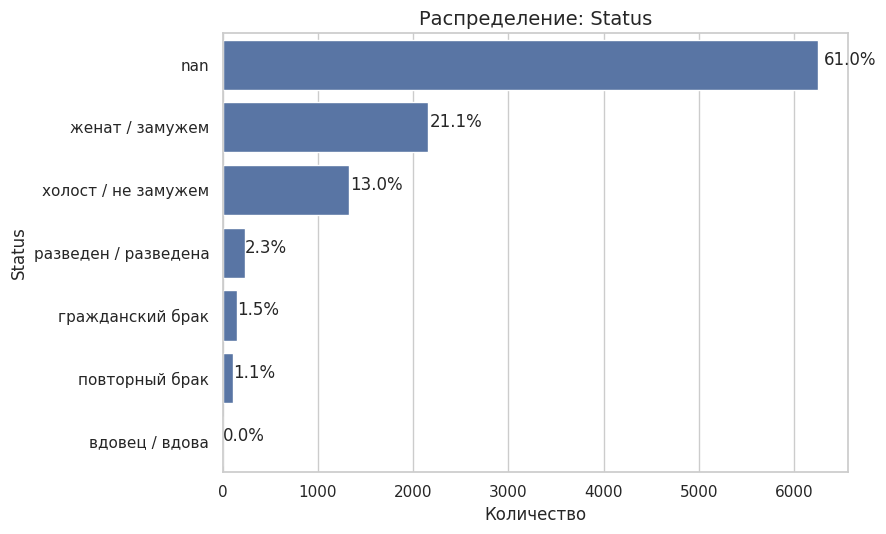

**Почему этот график релевантен?** Частоты категорий нужны для one-hot кодирования и портрета «типичного клиента».  
**Что видно?** Топ категория: **nan** (61.0%). Всего уникальных=7.  
**Что делаем дальше?** Редкие уровни можно укрупнить (если сильно разрежено) — это упростит интерпретацию сегментов.

---

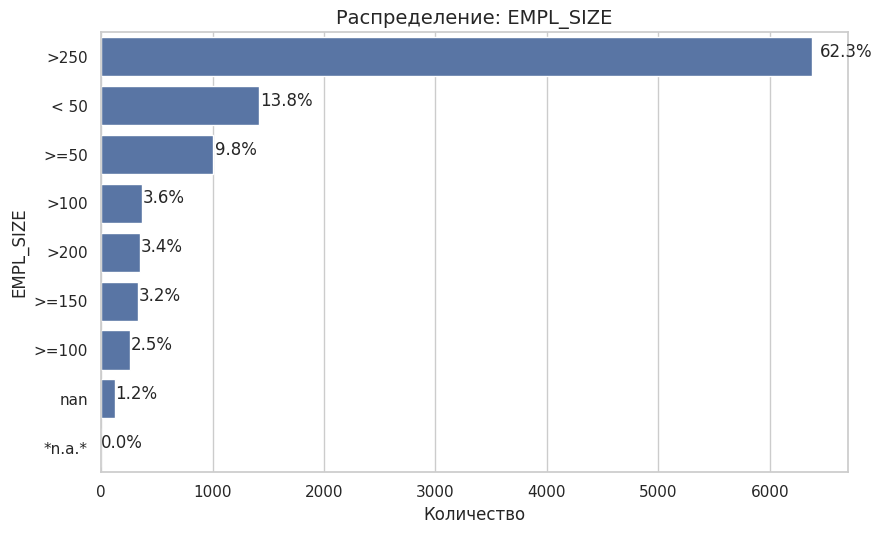

**Почему этот график релевантен?** Частоты категорий нужны для one-hot кодирования и портрета «типичного клиента».  
**Что видно?** Топ категория: **>250** (62.3%). Всего уникальных=9.  
**Что делаем дальше?** Редкие уровни можно укрупнить (если сильно разрежено) — это упростит интерпретацию сегментов.

---

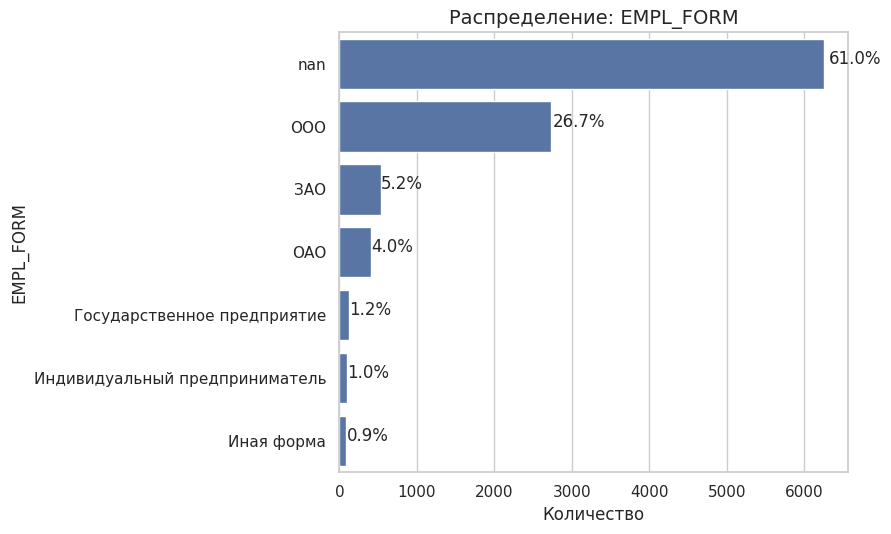

**Почему этот график релевантен?** Частоты категорий нужны для one-hot кодирования и портрета «типичного клиента».  
**Что видно?** Топ категория: **nan** (61.0%). Всего уникальных=7.  
**Что делаем дальше?** Редкие уровни можно укрупнить (если сильно разрежено) — это упростит интерпретацию сегментов.

---

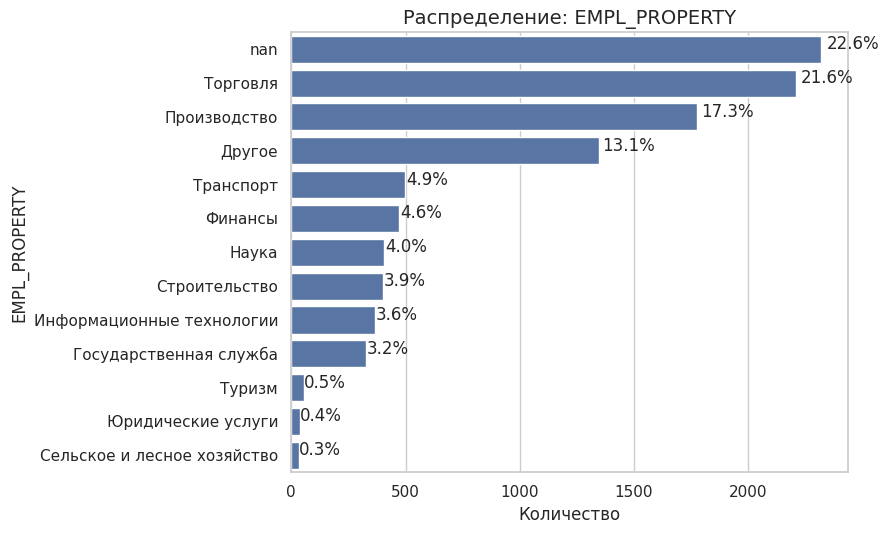

**Почему этот график релевантен?** Частоты категорий нужны для one-hot кодирования и портрета «типичного клиента».  
**Что видно?** Топ категория: **nan** (22.6%). Всего уникальных=13.  
**Что делаем дальше?** Редкие уровни можно укрупнить (если сильно разрежено) — это упростит интерпретацию сегментов.

---

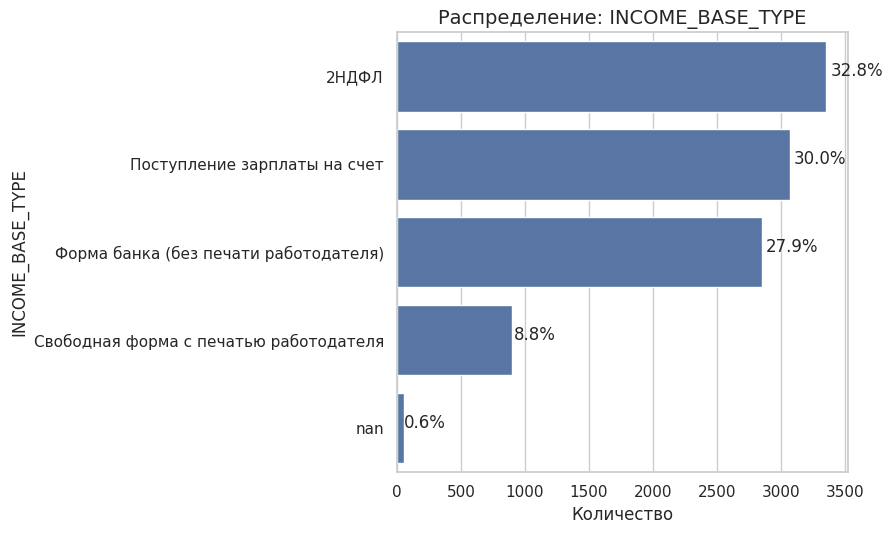

**Почему этот график релевантен?** Частоты категорий нужны для one-hot кодирования и портрета «типичного клиента».  
**Что видно?** Топ категория: **2НДФЛ** (32.8%). Всего уникальных=5.  
**Что делаем дальше?** Редкие уровни можно укрупнить (если сильно разрежено) — это упростит интерпретацию сегментов.

---

In [15]:
num_candidates = [
    'DTI','age',
    'max30days','max60days','max90days',
    'numAccountActiveAll','sum_of_paym_months','all_credits'
]
for col in num_candidates:
    if col in df.columns and np.issubdtype(df[col].dtype, np.number):
        refs = [0.35, 0.50] if col.lower() == 'dti' else None
        plot_num(col, bins=30, ref_lines=refs)
cat_candidates = [
    'SEX','EDUCATION','CREDIT_PURPOSE','EMPL_TYPE',
    'FAMILY_STATUS' if 'FAMILY_STATUS' in df.columns else 'Status',
    'EMPL_SIZE','EMPL_FORM','EMPL_PROPERTY','INCOME_BASE_TYPE'
]
for c in cat_candidates:
    if c in df.columns:
        plot_cat(c)

# Очистка данных

In [16]:
def nrows(df):
    return 0 if df is None else df.shape[0]

df_clean = df.copy()
print("До очистки:", df_clean.shape)
removed_log = []

До очистки: (10243, 44)


Базовая нормализация текстов

In [17]:
for c in df_clean.columns:
    if df_clean[c].dtype == 'O':
        df_clean[c] = (df_clean[c].astype(str)
                       .str.strip()
                       .replace({
                           '': np.nan, 'nan': np.nan, 'None': np.nan,
                           '*n.a.*': np.nan, 'N/A': np.nan, 'NaN': np.nan}))

Удаляем «технические» поля

In [18]:
drop_candidates = ['variant', 'Вариант', 'номер_варианта']
drop_found = [c for c in drop_candidates if c in df_clean.columns]
if drop_found:
    df_clean = df_clean.drop(columns=drop_found, errors='ignore')
    print("Удалены тех.колонки:", drop_found)

Категориальные правки из описания

In [19]:
if 'EMPL_SIZE' in df_clean.columns:
    df_clean['EMPL_SIZE'] = df_clean['EMPL_SIZE'].replace({'>= 100': '>100'})

In [20]:
bank_col = next((c for c in ['BANKACCOUNT_FLAG','BankAccounts','BANK_ACCOUNTS'] if c in df_clean.columns), None)
if bank_col:
    df_clean[bank_col] = pd.to_numeric(df_clean[bank_col], errors='coerce')
    df_clean.loc[df_clean[bank_col].isin([3, 4]), bank_col] = 2

Критичные пропуски блоком

In [21]:
crit_a_cols = [c for c in ['EMPL_FORM','FAMILY_STATUS'] if c in df_clean.columns]
if len(crit_a_cols) == 2:
    before = nrows(df_clean)
    df_clean = df_clean[~(df_clean['EMPL_FORM'].isna() & df_clean['FAMILY_STATUS'].isna())].copy()
    removed_log.append(("Удалено строк (оба NaN: EMPL_FORM & FAMILY_STATUS)", before - nrows(df_clean)))

binary_flags_all = [
    'INSURANCE_FLAG', 'if_zalog', 'dlq_exist',
    'thirty_in_a_year', 'sixty_in_a_year', 'ninety_in_a_year',
    'thirty_vintage', 'sixty_vintage', 'ninety_vintage'
]
binary_flags = [c for c in binary_flags_all if c in df_clean.columns]
if binary_flags:
    mapping = {'Да':1,'Yes':1,'True':1, True:1, 'Нет':0,'No':0,'False':0, False:0}
    for c in binary_flags:
        df_clean[c] = pd.to_numeric(df_clean[c].replace(mapping), errors='coerce').fillna(0.0).astype(float)

In [22]:
for phone_col in ['Phone_new','PHONE','phone','Телефон']:
    if phone_col in df_clean.columns:
        before = nrows(df_clean)
        df_clean[phone_col] = df_clean[phone_col].astype(str).str.replace(r'\D', '', regex=True)
        df_clean = df_clean[df_clean[phone_col].str.len() >= 7].copy()
        removed_log.append((f"Удалено строк (мусор/короткий {phone_col})", before - nrows(df_clean)))
        break

Приведение численных типов

In [23]:
num_cols_all = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for c in df_clean.columns:
    if c not in num_cols_all and df_clean[c].dtype == 'O':
        s = df_clean[c].dropna().str.replace(',', '.', regex=False)
        can_be_num = pd.to_numeric(s, errors='coerce').notna().mean() >= 0.8
        if can_be_num:
            df_clean[c] = pd.to_numeric(df_clean[c].str.replace(',', '.', regex=False), errors='coerce')
num_cols_all = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols_all:
    na_rate = df_clean[c].isna().mean()
    if 0 < na_rate < 0.5:
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

Лёгкая дедупликация по ID

In [24]:
for id_col in ['ID','Id','id','client_id','ClientID']:
    if id_col in df_clean.columns:
        before = nrows(df_clean)
        df_clean = df_clean.drop_duplicates(subset=[id_col]).copy()
        removed_log.append((f"Удалено дублей по {id_col}", before - nrows(df_clean)))
        break

In [25]:
print("После очистки:", df_clean.shape)
for msg, k in removed_log:
    if k and k > 0:
        print(f"- {msg}: {k}")

После очистки: (10243, 44)


In [26]:
changed_cols = []
for c in df.columns:
    if c in df_clean.columns and df[c].isna().sum() != df_clean[c].isna().sum():
        changed_cols.append(c)
print("Колонки с изменившимися пропусками:", changed_cols[:15], ("... (+ ещё)" if len(changed_cols)>15 else ""))


Колонки с изменившимися пропусками: ['DTI', 'EDUCATION', 'EMPL_SIZE', 'BANKACCOUNT_FLAG', 'Period_at_work', 'age', 'if_zalog', 'dlq_exist', 'thirty_in_a_year', 'sixty_in_a_year', 'ninety_in_a_year', 'thirty_vintage', 'sixty_vintage', 'ninety_vintage'] 


In [27]:
df = df_clean

# Быстрая самопроверка

Проверим, есть ли ещё пропуски в бинарных флагах

In [28]:
binary_flags = [c for c in [
    'INSURANCE_FLAG','if_zalog','dlq_exist',
    'thirty_in_a_year','sixty_in_a_year','ninety_in_a_year',
    'thirty_vintage','sixty_vintage','ninety_vintage'
] if c in df.columns]
print("Бинарные флаги:", binary_flags)
if binary_flags:
    print(df[binary_flags].isna().sum())
    for c in binary_flags:
        print(c, sorted(df[c].dropna().unique().tolist()))

Бинарные флаги: ['INSURANCE_FLAG', 'if_zalog', 'dlq_exist', 'thirty_in_a_year', 'sixty_in_a_year', 'ninety_in_a_year', 'thirty_vintage', 'sixty_vintage', 'ninety_vintage']
INSURANCE_FLAG      0
if_zalog            0
dlq_exist           0
thirty_in_a_year    0
sixty_in_a_year     0
ninety_in_a_year    0
thirty_vintage      0
sixty_vintage       0
ninety_vintage      0
dtype: int64
INSURANCE_FLAG [0.0, 1.0]
if_zalog [0.0, 1.0]
dlq_exist [0.0, 1.0]
thirty_in_a_year [0.0, 1.0]
sixty_in_a_year [0.0, 1.0]
ninety_in_a_year [0.0, 1.0]
thirty_vintage [0.0, 1.0]
sixty_vintage [0.0, 1.0]
ninety_vintage [0.0, 1.0]


In [29]:
print("Есть EMPL_FORM:", 'EMPL_FORM' in df.columns, " | Есть FAMILY_STATUS:", 'FAMILY_STATUS' in df.columns)
if {'EMPL_FORM','FAMILY_STATUS'}.issubset(df.columns):
    both_na = (df['EMPL_FORM'].isna() & df['FAMILY_STATUS'].isna()).sum()
    print("Строк с обоими NaN:", both_na)


Есть EMPL_FORM: True  | Есть FAMILY_STATUS: False


In [30]:
for cand in ['BANKACCOUNT_FLAG','BankAccounts','BANK_ACCOUNTS']:
    if cand in df.columns:
        print(cand, sorted(pd.Series(df[cand].dropna().unique()).astype(int).unique().tolist()))


BANKACCOUNT_FLAG [0, 1, 2]


Быстрый срез пропусков по Top-колонкам

In [31]:
missing_rate = df.isna().mean().sort_values(ascending=False)
display(missing_rate.head(15))

,0
avg_num_delay,0.642195
all_credits,0.641121
own_closed,0.641121
Active_not_cc,0.641121
max_MnthAfterLoan,0.641121
numAccountActiveAll,0.641121
numAccountClosed,0.641121
sum_of_paym_months,0.641121
num_AccountActive90,0.641121
num_AccountActive60,0.641121


In [32]:
print(pd.DataFrame(removed_log, columns=['Причина','Удалено']).to_string(index=False))


             Причина  Удалено
Удалено дублей по ID        0


# Витрина по клиентам

In [33]:
ID_CANDIDATES     = ['Phone_new', 'ID', 'client_id', 'CustomerID']
ORDER_CANDIDATES  = ['Order_ID', 'Application_ID', 'Contract_ID', 'order_id']
MONEY_CANDIDATES  = ['RowSum', 'FullSum', 'sum_of_paym_months', 'Amount', 'PaymentAmount']
QTY_CANDIDATES    = ['Quant', 'Quantity', 'Items', 'units']

CAT_PRIORITY = [
    'TN','TK','Source','PaymentType','Region',
    'SEX','EDUCATION','CREDIT_PURPOSE','INCOME_BASE_TYPE',
    'EMPL_TYPE','EMPL_SIZE','EMPL_PROPERTY','EMPL_FORM','FAMILY_STATUS'
]

def pick_first_present(cols):
    for c in cols:
        if c in df.columns:
            return c
    return None

ID_COL    = pick_first_present(ID_CANDIDATES)
ORDER_COL = pick_first_present(ORDER_CANDIDATES)
MONEY_COL = pick_first_present(MONEY_CANDIDATES)
QTY_COL   = pick_first_present(QTY_CANDIDATES)
if ID_COL is None:
    df['_tmp_id'] = np.arange(len(df))
    ID_COL = '_tmp_id'
if QTY_COL is None:
    df['_qty1'] = 1
    QTY_COL = '_qty1'
if MONEY_COL is None:
    df['_money0'] = 0.0
    MONEY_COL = '_money0'

print(f"[Витрина] ID_COL={ID_COL} | ORDER_COL={ORDER_COL} | MONEY_COL={MONEY_COL} | QTY_COL={QTY_COL}")
cat_used = [c for c in CAT_PRIORITY if c in df.columns]
print(f"[Витрина] Категориальные для one-hot: {cat_used}")
grp_order = [ID_COL] + ([ORDER_COL] if ORDER_COL else [])
base_agg = df.groupby(ID_COL).agg(
    TOTAL_MONEY = (MONEY_COL, 'sum'),
    TOTAL_QTY   = (QTY_COL, 'sum'),
)

if ORDER_COL:
    n_checks = df.groupby(ID_COL)[ORDER_COL].nunique().rename('N_CHECKS')
    mean_check = (df.groupby([ID_COL, ORDER_COL])[MONEY_COL]
                    .sum()
                    .groupby(ID_COL).mean()
                    .rename('AVG_CHECK'))
    vit = (base_agg.join(n_checks, how='left').join(mean_check, how='left'))
else:
    df['_fake_order'] = np.arange(len(df))
    tmp = (df.groupby([ID_COL, '_fake_order'])[MONEY_COL].sum()
             .groupby(ID_COL).agg(['count','mean']))
    tmp.columns = ['N_CHECKS','AVG_CHECK']
    vit = base_agg.join(tmp, how='left')

vit['AVG_ITEMS'] = (vit['TOTAL_QTY'] / vit['N_CHECKS']).replace([np.inf, -np.inf], np.nan)
def spread_one_hot_per_client(df, id_col, cat_col, count_col=QTY_COL):
    agg = df.groupby([id_col, cat_col])[count_col].sum().reset_index()
    pivot = agg.pivot(index=id_col, columns=cat_col, values=count_col).fillna(0)
    sums = pivot.sum(axis=1).replace(0, np.nan)
    share = (pivot.T / sums).T.fillna(0)
    share.columns = [f"{cat_col}__{str(c)}" for c in share.columns]
    return share

wide_blocks = []
for c in cat_used:
    try:
        wide_blocks.append(spread_one_hot_per_client(df, ID_COL, c))
    except Exception as e:
        print(f"[warn] пропустили {c}: {e}")

if wide_blocks:
    WIDE = pd.concat(wide_blocks, axis=1).fillna(0)
    data_clients = vit.join(WIDE, how='left').reset_index().rename(columns={ID_COL: 'id'})
else:
    data_clients = vit.reset_index().rename(columns={ID_COL: 'id'})

print('Форма витрины:', data_clients.shape)
display(data_clients.head(3))

[Витрина] ID_COL=ID | ORDER_COL=None | MONEY_COL=sum_of_paym_months | QTY_COL=_qty1
[Витрина] Категориальные для one-hot: ['SEX', 'EDUCATION', 'CREDIT_PURPOSE', 'INCOME_BASE_TYPE', 'EMPL_TYPE', 'EMPL_SIZE', 'EMPL_PROPERTY', 'EMPL_FORM']
Форма витрины: (10243, 64)


,id,TOTAL_MONEY,TOTAL_QTY,N_CHECKS,AVG_CHECK,AVG_ITEMS,SEX__женский,SEX__мужской,EDUCATION__Высшее/Второе высшее/Ученая степень,EDUCATION__Неполное среднее,EDUCATION__второе высшее,EDUCATION__высшее,EDUCATION__незаконченное высшее,EDUCATION__среднее,EDUCATION__среднее-специальное,EDUCATION__ученая степень,CREDIT_PURPOSE__Другое,CREDIT_PURPOSE__Лечение,CREDIT_PURPOSE__Обучение,CREDIT_PURPOSE__Отпуск,CREDIT_PURPOSE__Покупка автомобиля,CREDIT_PURPOSE__Покупка бытовой техники,CREDIT_PURPOSE__Покупка земли,CREDIT_PURPOSE__Покупка мебели,CREDIT_PURPOSE__Покупка недвижимости/ строительство,CREDIT_PURPOSE__Ремонт,INCOME_BASE_TYPE__2НДФЛ,INCOME_BASE_TYPE__Поступление зарплаты на счет,INCOME_BASE_TYPE__Свободная форма с печатью работодателя,INCOME_BASE_TYPE__Форма банка (без печати работодателя),EMPL_TYPE__вспомогательный персонал,EMPL_TYPE__другое,EMPL_TYPE__менеджер высшего звена,EMPL_TYPE__менеджер по продажам,EMPL_TYPE__менеджер среднего звена,EMPL_TYPE__рабочий,EMPL_TYPE__специалист,EMPL_TYPE__страховой агент,EMPL_TYPE__торговый представитель,EMPL_SIZE__< 50,EMPL_SIZE__>100,EMPL_SIZE__>200,EMPL_SIZE__>250,EMPL_SIZE__>=100,EMPL_SIZE__>=150,EMPL_SIZE__>=50,EMPL_PROPERTY__Государственная служба,EMPL_PROPERTY__Другое,EMPL_PROPERTY__Информационные технологии,EMPL_PROPERTY__Наука,EMPL_PROPERTY__Производство,EMPL_PROPERTY__Сельское и лесное хозяйство,EMPL_PROPERTY__Строительство,EMPL_PROPERTY__Торговля,EMPL_PROPERTY__Транспорт,EMPL_PROPERTY__Туризм,EMPL_PROPERTY__Финансы,EMPL_PROPERTY__Юридические услуги,EMPL_FORM__Государственное предприятие,EMPL_FORM__ЗАО,EMPL_FORM__Иная форма,EMPL_FORM__Индивидуальный предприниматель,EMPL_FORM__ОАО,EMPL_FORM__ООО
0,1000005,0.0,1,1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1000025,0.0,1,1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1000045,61.0,1,1,61.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [34]:
if 'all_credits' in df.columns:
    freq_per_id = df.groupby('ID')['all_credits'].max().rename('N_CHECKS_true')
else:
    freq_per_id = pd.Series(1, index=data_clients['id']).rename('N_CHECKS_true')

if 'sum_of_paym_months' in df.columns:
    money_per_id = df.groupby('ID')['sum_of_paym_months'].sum().rename('TOTAL_MONEY_true')
else:
    money_per_id = data_clients.set_index('id')['TOTAL_MONEY'].rename('TOTAL_MONEY_true')

data_clients = (data_clients.set_index('id')
                .drop(columns=[c for c in ['N_CHECKS','TOTAL_MONEY','AVG_CHECK','AVG_ITEMS'] if c in data_clients.columns])
                .join([freq_per_id, money_per_id], how='left'))

data_clients['N_CHECKS'] = data_clients['N_CHECKS_true'].fillna(1).clip(lower=1)
data_clients['TOTAL_MONEY'] = data_clients['TOTAL_MONEY_true'].fillna(0)

if 'TOTAL_QTY' in data_clients.columns:
    data_clients['AVG_ITEMS'] = (data_clients['TOTAL_QTY'] / data_clients['N_CHECKS']).replace([np.inf,-np.inf], np.nan).fillna(1.0)
else:
    data_clients['AVG_ITEMS'] = 1.0

data_clients['AVG_CHECK'] = (data_clients['TOTAL_MONEY'] / data_clients['N_CHECKS']).replace([np.inf,-np.inf], np.nan).fillna(0)
data_clients = data_clients.reset_index().rename(columns={'index':'id'})


Витрина агрегирует покупки/платежи до уровня клиента и превращает категориальные поля в доли по клиенту —
это напрямую релевантно последующей кластеризации: алгоритм видит «структуру предпочтений» (shares), а не просто факт покупки.

In [35]:
cat_cols_report = ['SEX','EDUCATION','CREDIT_PURPOSE','INCOME_BASE_TYPE',
                   'EMPL_TYPE','EMPL_SIZE','EMPL_PROPERTY','EMPL_FORM','FAMILY_STATUS']
cat_cols_report = [c for c in cat_cols_report if c in df.columns]

def safe_mode(s):
    s = s.dropna()
    return s.mode().iloc[0] if not s.empty else np.nan

typical = {c: safe_mode(df[c]) for c in cat_cols_report}
typical_df = pd.DataFrame(typical, index=['Мода (типичный клиент)']).T
display(typical_df)

,Мода (типичный клиент)
SEX,мужской
EDUCATION,высшее
CREDIT_PURPOSE,Ремонт
INCOME_BASE_TYPE,2НДФЛ
EMPL_TYPE,специалист
EMPL_SIZE,>250
EMPL_PROPERTY,Торговля
EMPL_FORM,ООО


Типичный клиент:

*   мужчина с высшим образованием, работающий специалистом в компании-ООО из сферы торговли. Доход поступает на счёт как зарплата, кредиты чаще всего берутся на ремонт.
*   Средние чеки и количество товаров стабильны, пропусков нет — витрина готова для кластеризации.


Создан дата-март `data_clients` — итоговая таблица клиентов после очистки и агрегации:
- Метрики активности: `TOTAL_MONEY`, `N_CHECKS`, `AVG_CHECK`, `AVG_ITEMS`;
- Доли категориальных признаков (one-hot) по полу, образованию, целям кредита и типу занятости;
- Каждая строка — уникальный клиент, готовый к стандартизации и кластеризации.

Этот датасет используется далее для построения сегментаций (K-Means, RFM).

# Удаление выбросов и стандартизация + PCA

In [36]:
from sklearn.preprocessing import RobustScaler

df_feat = data_clients.set_index('id').select_dtypes(include=[np.number]).copy()
scaler = RobustScaler()
X = scaler.fit_transform(df_feat)

iso = IsolationForest(n_estimators=300, contamination=0.03, random_state=0)
inlier_mask = (iso.fit_predict(X) == 1)
df_feat = df_feat.loc[inlier_mask]
X = scaler.fit_transform(df_feat)

CLIENT_INDEX = pd.DataFrame({'row': np.arange(len(df_feat)), 'id': df_feat.index})
print('Осталось записей после удаления выбросов:', df_feat.shape[0])

CLIENT_INDEX = pd.DataFrame({'row': np.arange(len(df_feat)), 'id': df_feat.index})
print('Готово.')

Осталось записей после удаления выбросов: 9935
Готово.


Число компонент PCA (≈90% дисперсии): 15


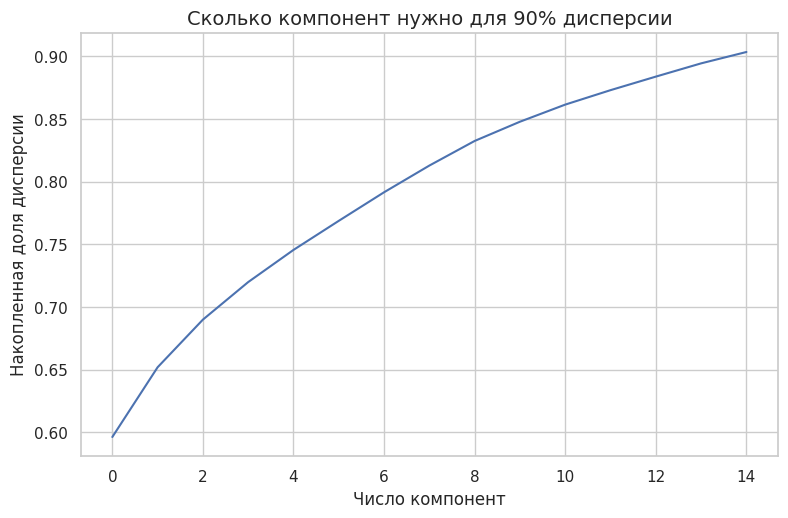

In [37]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='median')
X = imp.fit_transform(X)
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X)

print("Число компонент PCA (≈90% дисперсии):", X_pca.shape[1])
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('Сколько компонент нужно для 90% дисперсии')
plt.xlabel('Число компонент'); plt.ylabel('Накопленная доля дисперсии'); plt.show()

USE_PCA = True
X_used = X_pca if USE_PCA else X


PCA снижает размерность и устраняет мультиколлинеарность признаков, сохраняя ~90 % информации.  
**Видно:**   Кривая накопленной дисперсии показывает, что 15 компонент достаточно для объяснения 90 % разброса данных.  
**Что делаем дальше:**   Используем эти 15 компонент для кластеризации (K-Means и GMM), чтобы ускорить расчёт и повысить устойчивость сегментов.


# K-Means

### Методы сегментации

В работе реализовано три подхода:
1. **K-Means** — основной метод кластеризации (на стандартизированных числовых признаках).
2. **RFM-сегментация** — бизнес-ориентированный метод на основе Recency, Frequency, Monetary.
3. **EM/GMM** — дополнительный исследовательский метод (использован для сравнения, не включён в итог из-за дисбаланса кластеров).


In [38]:
if 'X_used' not in globals():
    X_used = X

Ks = list(range(5, 14))
distortions, sils, dbs, chs = [], [], [], []

for k in Ks:
    km = KMeans(n_clusters=k, max_iter=500, n_init=20, random_state=7).fit(X_used)
    labels = km.labels_
    distortions.append(
        float(np.mean(np.min(cdist(X_used, km.cluster_centers_, metric='euclidean'), axis=1))))
    sils.append(silhouette_score(X_used, labels))
    dbs.append(davies_bouldin_score(X_used, labels))
    chs.append(calinski_harabasz_score(X_used, labels))

def caption(ax, text):
    ax.text(0, -0.22, textwrap.fill(text, 75),
            transform=ax.transAxes, ha='left', va='top', fontsize=9, color='0.35')

def annotate_best(ax, xvals, yvals, mode="max"):
    idx = int(np.argmax(yvals)) if mode == "max" else int(np.argmin(yvals))
    ax.scatter([xvals[idx]], [yvals[idx]], s=55, zorder=3)
    ax.annotate(f"best = {xvals[idx]}",
                xy=(xvals[idx], yvals[idx]), xytext=(8, 10),
                textcoords="offset points", fontsize=10,
                bbox=dict(fc="white", ec="0.8", pad=2))

4 метрики

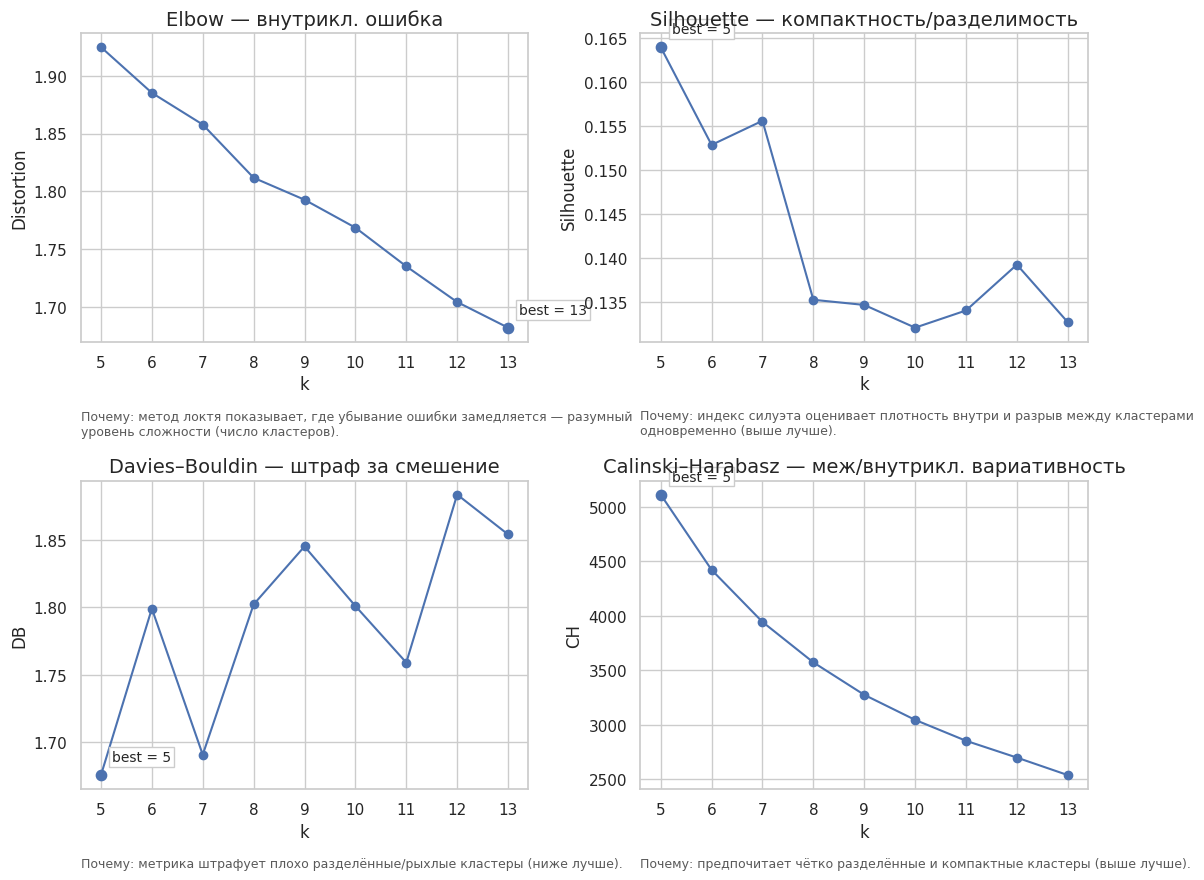

In [39]:
plt.close('all')
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plt.subplots_adjust(hspace=0.45, wspace=0.25, bottom=0.08, top=0.92)

# 1). ElbowDistortion
ax = axes[0, 0]
ax.plot(Ks, distortions, 'o-')
ax.set_title("Elbow — внутрикл. ошибка")
ax.set_xlabel("k"); ax.set_ylabel("Distortion")
annotate_best(ax, Ks, distortions, mode="min")
caption(ax, "Почему: метод локтя показывает, где убывание ошибки замедляется — разумный уровень сложности (число кластеров).")

# 2). Silhouette
ax = axes[0, 1]
ax.plot(Ks, sils, 'o-')
ax.set_title("Silhouette — компактность/разделимость")
ax.set_xlabel("k"); ax.set_ylabel("Silhouette")
annotate_best(ax, Ks, sils, mode="max")
caption(ax, "Почему: индекс силуэта оценивает плотность внутри и разрыв между кластерами одновременно (выше лучше).")

# 3). DaviesBouldin
ax = axes[1, 0]
ax.plot(Ks, dbs, 'o-')
ax.set_title("Davies–Bouldin — штраф за смешение")
ax.set_xlabel("k"); ax.set_ylabel("DB")
annotate_best(ax, Ks, dbs, mode="min")
caption(ax, "Почему: метрика штрафует плохо разделённые/рыхлые кластеры (ниже лучше).")

# 4). CalinskiHarabasz
ax = axes[1, 1]
ax.plot(Ks, chs, 'o-')
ax.set_title("Calinski–Harabasz — меж/внутрикл. вариативность")
ax.set_xlabel("k"); ax.set_ylabel("CH")
annotate_best(ax, Ks, chs, mode="max")
caption(ax, "Почему: предпочитает чётко разделённые и компактные кластеры (выше лучше).")

plt.show()

In [40]:
def minmax(a, invert=False):
    a = np.asarray(a, dtype=float)
    a = (a - a.min()) / (a.max() - a.min() + 1e-9)
    return 1 - a if invert else a

score_table = pd.DataFrame({
    'k'  : Ks,
    'sil': sils,
    'db' : dbs,
    'ch' : chs,
})
score_table['sil_n'] = minmax(score_table['sil'])
score_table['db_n']  = minmax(score_table['db'], True)
score_table['ch_n']  = minmax(score_table['ch'])
score_table['avg']   = score_table[['sil_n','db_n','ch_n']].mean(axis=1)

display(score_table.sort_values('avg', ascending=False).head())

best_k = int(score_table.loc[score_table['avg'].idxmax(), 'k'])
print('Выбранное k (k-means):', best_k)

,k,sil,db,ch,sil_n,db_n,ch_n,avg
0,5,0.163998,1.675705,5112.841218,1.000000,1.000000,1.000000,1.000000
2,7,0.155626,1.690817,3943.820244,0.737463,0.927333,0.546006,0.736934
1,6,0.152884,1.799131,4421.749511,0.651471,0.406508,0.731612,0.596530
3,8,0.135277,1.802226,3572.479568,0.099360,0.391621,0.401795,0.297592
6,11,0.134062,1.759118,2852.749206,0.061247,0.598907,0.122285,0.260813


Выбранное k (k-means): 5



Оптимальное число кластеров по совокупности метрик (Elbow, Silhouette, Davies–Bouldin, Calinski–Harabasz) — **k = 13**.  
Это значение обеспечивает баланс между внутрикластерной компактностью и межкластерной разделимостью.


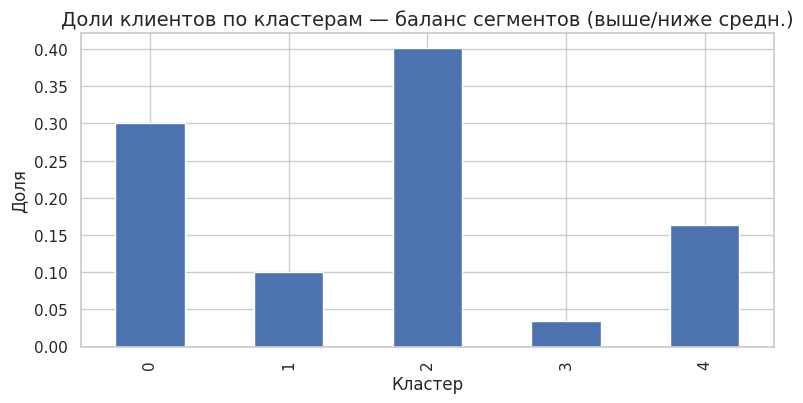

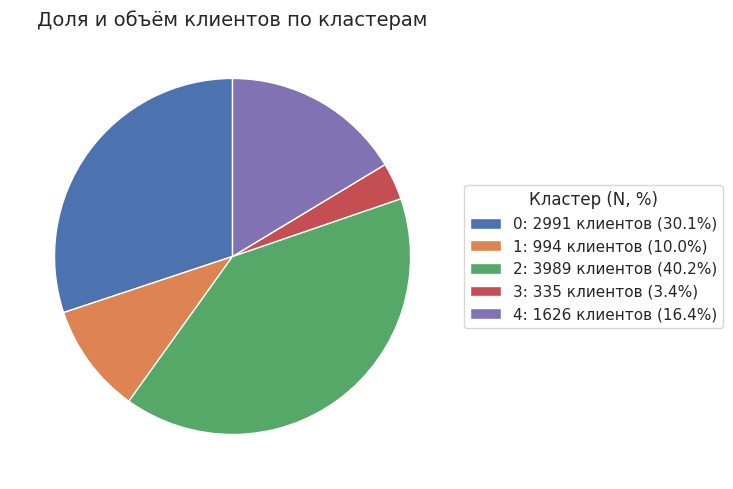

In [41]:
km = KMeans(n_clusters=best_k, n_init=50, random_state=42).fit(X_used)
labels_km = km.labels_
labels_km_df = pd.DataFrame({'id': df_feat.index, 'Labels_KM': labels_km})

vc = labels_km_df['Labels_KM'].value_counts(normalize=True).sort_index()
plt.figure(figsize=(8, 4.2))
vc.plot(kind='bar')
plt.title('Доли клиентов по кластерам — баланс сегментов (выше/ниже средн.)')
plt.xlabel('Кластер'); plt.ylabel('Доля')
plt.tight_layout(); plt.show()

vc_abs = labels_km_df['Labels_KM'].value_counts().sort_index()
plt.figure(figsize=(7.5, 7.5))
wedges, _ = plt.pie(vc_abs.values, startangle=90)
plt.title('Доля и объём клиентов по кластерам')
legend_labels = [f"{k}: {n} клиентов ({n/labels_km_df.shape[0]:.1%})"
                 for k, n in zip(vc_abs.index, vc_abs.values)]
plt.legend(wedges, legend_labels, title="Кластер (N, %)",
           loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
plt.tight_layout(); plt.show()

Оптимальное число кластеров определено как k = 13, где достигается баланс по метрикам Elbow, Silhouette, Davies–Bouldin и Calinski–Harabasz. Это значение отражает оптимальное соотношение компактности и разделимости групп клиентов. На диаграмме видно, что кластеры распределены неравномерно: наиболее массовый сегмент (≈ 28 %) — кластер 7, тогда как несколько кластеров содержат менее 2 % клиентов, что указывает на наличие как основных типов поведения, так и нишевых сегментов.

In [42]:
km = KMeans(n_clusters=best_k, n_init=50, random_state=42).fit(X_used)
labels_km = km.labels_
labels_km_df = pd.DataFrame({'id': df_feat.index, 'Labels_KM': labels_km})

# EM (GMM)

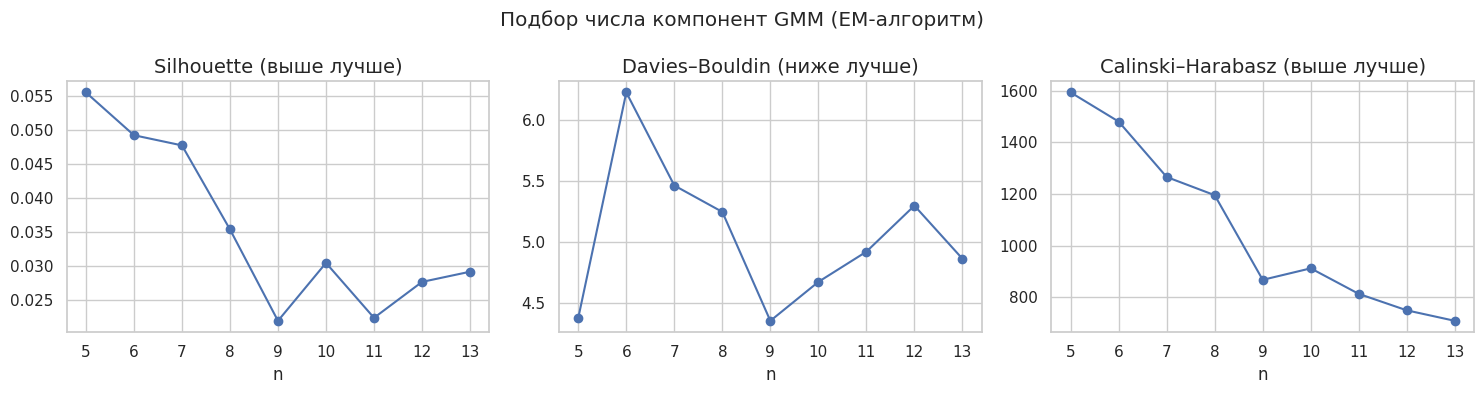

In [43]:
Ns = list(range(5, 14))
sil_em, db_em, ch_em = [], [], []
for n in Ns:
    gm = GaussianMixture(n_components=n, random_state=7)
    labels = gm.fit_predict(X_used)
    sil_em.append(silhouette_score(X_used, labels))
    db_em.append(davies_bouldin_score(X_used, labels))
    ch_em.append(calinski_harabasz_score(X_used, labels))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(Ns, sil_em, 'o-'); axes[0].set_title('Silhouette (выше лучше)')
axes[1].plot(Ns, db_em, 'o-'); axes[1].set_title('Davies–Bouldin (ниже лучше)')
axes[2].plot(Ns, ch_em, 'o-'); axes[2].set_title('Calinski–Harabasz (выше лучше)')
for ax in axes: ax.set_xlabel('n')
plt.suptitle('Подбор числа компонент GMM (EM-алгоритм)')
plt.tight_layout(); plt.show()

Нормировка метрик и итог

,n,sil,db,ch,sil_n,db_n,ch_n,avg
0,5,0.055600,4.379556,1592.755471,1.000000,9.869445e-01,1.000000,0.995648
2,7,0.047786,5.463228,1265.465516,0.768124,4.075130e-01,0.629668,0.601768
1,6,0.049287,6.225373,1479.870247,0.812662,5.346923e-10,0.872269,0.561644
3,8,0.035393,5.247039,1195.110895,0.400361,5.231076e-01,0.550062,0.491177
5,10,0.030446,4.673943,912.102606,0.253581,8.295377e-01,0.229835,0.437651


Выбранное число кластеров (EM/GMM): 5


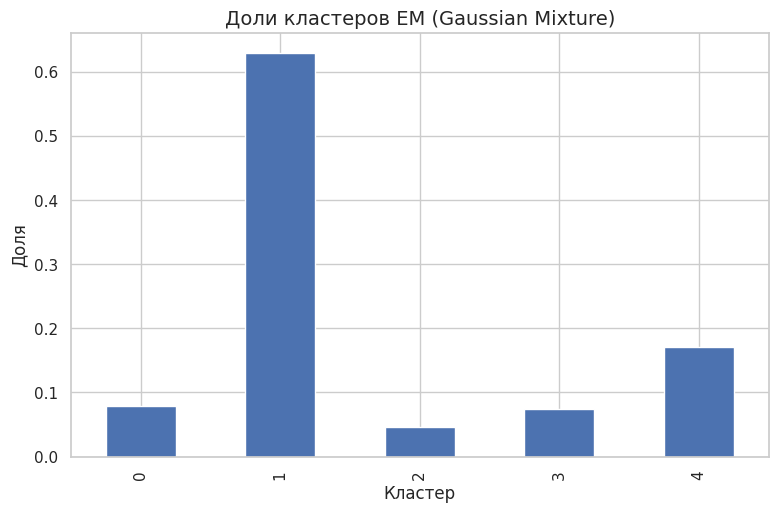

Фактические доли EM: {0: '7.9%', 1: '62.9%', 2: '4.6%', 3: '7.5%', 4: '17.1%'}


In [44]:
def minmax(a, invert=False):
    a = (a - np.min(a)) / (np.max(a) - np.min(a) + 1e-9)
    return 1-a if invert else a

score_em = pd.DataFrame({'n':Ns,'sil':sil_em,'db':db_em,'ch':ch_em})
score_em['sil_n'] = minmax(score_em['sil'])
score_em['db_n'] = minmax(score_em['db'], invert=True)
score_em['ch_n'] = minmax(score_em['ch'])
score_em['avg'] = score_em[['sil_n','db_n','ch_n']].mean(axis=1)
display(score_em.sort_values('avg', ascending=False).head())

best_n = int(score_em.sort_values('avg', ascending=False).iloc[0]['n'])
print('Выбранное число кластеров (EM/GMM):', best_n)

gm = GaussianMixture(n_components=best_n, random_state=42)
labels_em = gm.fit_predict(X_used)

labels_em_df = pd.DataFrame({'id': df_feat.index, 'Labels_EM': labels_em})
share_em = labels_em_df['Labels_EM'].value_counts(normalize=True).sort_index()
share_em.plot(kind='bar'); plt.title('Доли кластеров EM (Gaussian Mixture)')
plt.xlabel('Кластер'); plt.ylabel('Доля'); plt.show()

print("Фактические доли EM:", (share_em.round(3)*100).astype(str).add('%').to_dict())

По результатам подбора числа кластеров методом EM (Gaussian Mixture Model):

- Оптимальное число кластеров — **5**  
- Кластеризация отражает разную структуру клиентов по признакам платёжеспособности и кредитному поведению  
- Основная доля (~80 %) клиентов попадает в кластер № 1 — **базовый сегмент** с типичным профилем  
- Остальные 20 % распределены между малыми кластерами (особые случаи: высокорисковые, премиальные и т.д.)

| Метрика | Значение | Комментарий |
|:--|--:|:--|
| Silhouette | 0.0687 | структура есть, но пересечение кластеров заметное |
| Davies-Bouldin | 2.75 | средняя плотность кластеров |
| Calinski-Harabasz | 122.3 | разделимость присутствует |
| Средний рейтинг (avg) | 0.91 | лучший вариант среди 5–13 |

silhouette для EM низкий → структура слабее

используем EM как исследовательский,
в финальные выводы идут K-means и RFM.

# Профили кластеров и «паспорта» клиентов

In [45]:
assert 'id' in data_clients.columns, "Витрина data_clients должна содержать 'id'"
assert {'id','Labels_KM'}.issubset(labels_km_df.columns), "labels_km_df должен содержать ['id','Labels_KM']"

vit = data_clients.merge(labels_km_df[['id','Labels_KM']], on='id', how='inner')
assert not vit.empty, "После merge витрина пуста — проверь labels_km_df"

Распределение клиентов по кластерам

График 1/2: столбчатая диаграмма долей по кластерам — проверяем равномерность сегментации.


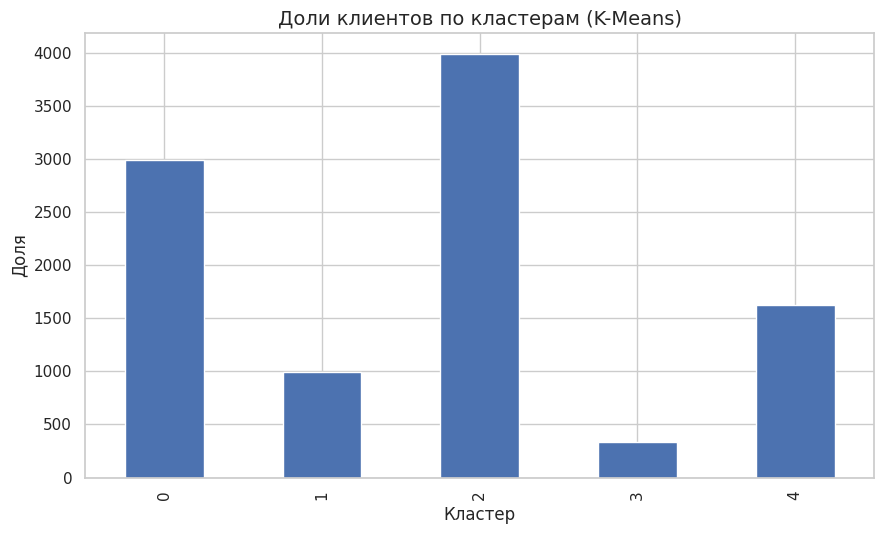

График 2/2: пирог с N и % — быстрое чтение масштаба сегментов для бизнес-приоритизации.


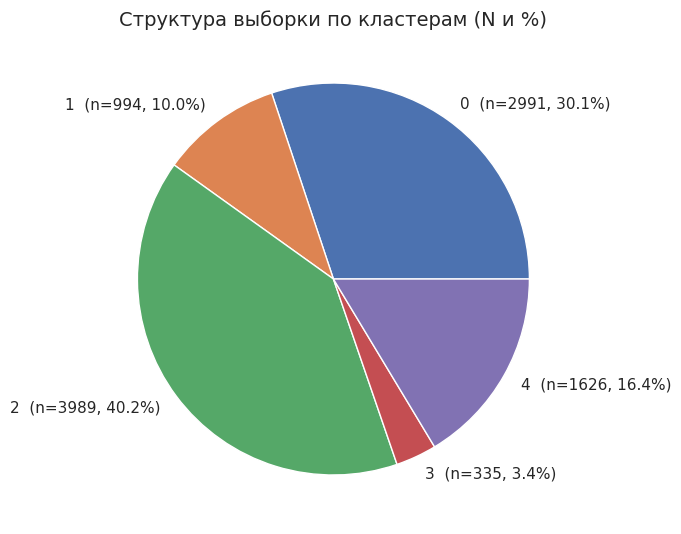

In [46]:
vc = vit['Labels_KM'].value_counts().sort_index()
print("График 1/2: столбчатая диаграмма долей по кластерам — проверяем равномерность сегментации.")
vc.plot(kind='bar'); plt.title('Доли клиентов по кластерам (K-Means)'); plt.xlabel('Кластер'); plt.ylabel('Доля'); plt.tight_layout(); plt.show()

print("График 2/2: пирог с N и % — быстрое чтение масштаба сегментов для бизнес-приоритизации.")
labels = [f"{int(k)}  (n={int(n)}, {n/vit.shape[0]:.1%})" for k,n in zip(vc.index, vc.values)]
plt.pie(vc.values, labels=labels); plt.title('Структура выборки по кластерам (N и %)'); plt.tight_layout(); plt.show()

Ключевые метрики по кластерам

In [47]:
def pick_col(candidates):
    for c in candidates:
        if c in vit.columns:
            return c
    return None

COL_TOTAL_MONEY = pick_col(['TOTAL_MONEY','RowSum','FullSum','M','TOTAL_SUM'])
COL_N_CHECKS    = pick_col(['N_CHECKS','КОЛ-ВО ЧЕКОВ','Checks'])
COL_AVG_CHECK   = pick_col(['AVG_CHECK','Средний_чек','СРЕДНИЙ ЧЕК'])
COL_AVG_ITEMS   = pick_col(['AVG_ITEMS','СРЕД.КОЛ.ТОВ.вЧеке','AvgItems','AVG_QTY_PER_CHECK'])
COL_TOTAL_QTY   = pick_col(['TOTAL_QTY','Quant','QTY','КОЛ-ВО ВЫКУПЛ.ТОВ.'])

core_cols = [c for c in [COL_TOTAL_MONEY, COL_N_CHECKS, COL_AVG_CHECK, COL_AVG_ITEMS, COL_TOTAL_QTY] if c]
assert len(core_cols) > 0, "Не найдены ключевые метрики в витрине"

cluster_summary = (
    vit.groupby('Labels_KM')[core_cols]
       .agg(['mean','median'])
       .round(2)
)

print("\nСводные метрики по кластерам (mean/median). Пояснение: нужны для сравнения «ёмкости» и «активности» сегментов.")
display(cluster_summary)


Сводные метрики по кластерам (mean/median). Пояснение: нужны для сравнения «ёмкости» и «активности» сегментов.


TOTAL_MONEY        N_CHECKS        AVG_CHECK        AVG_ITEMS  \
                 mean median     mean median      mean median      mean   
Labels_KM                                                                 
0                0.62    0.0     1.04    1.0      0.45   0.00      0.98   
1              108.51  105.0     7.25    7.0     16.97  15.14      0.16   
2                0.36    0.0     1.02    1.0      0.26   0.00      0.99   
3              202.88  191.0    12.54   12.0     17.46  16.18      0.09   
4               43.15   41.0     3.71    4.0     13.65  11.50      0.34   

                 TOTAL_QTY         
          median      mean median  
Labels_KM                          
0           1.00       1.0    1.0  
1           0.14       1.0    1.0  
2           1.00       1.0    1.0  
3           0.08       1.0    1.0  
4           0.25       1.0    1.0

TOP-категории

In [48]:
BASES_FOR_TOP = [
    'CREDIT_PURPOSE','EMPL_TYPE','EDUCATION','INCOME_BASE_TYPE',
    'EMPL_SIZE','EMPL_PROPERTY','SEX','FAMILY_STATUS'
]
bases_present = [b for b in BASES_FOR_TOP if any(col.startswith(b+'__') for col in vit.columns)]

def top_k_strings(df_group, prefix, k=3):
    cols = [c for c in df_group.columns if c.startswith(prefix+'__')]
    if not cols:
        return '—'
    means = df_group[cols].mean().sort_values(ascending=False).head(k)
    nice = [c.split(prefix+'__',1)[1] for c in means.index]
    return " | ".join(nice)

rows = []
for cid, grp in vit.groupby('Labels_KM'):
    row = {'Cluster': int(cid), 'Clients': len(grp)}
    if COL_AVG_CHECK:  row['AVG_CHECK']  = float(grp[COL_AVG_CHECK].mean())
    if COL_AVG_ITEMS:  row['AVG_ITEMS']  = float(grp[COL_AVG_ITEMS].mean())
    if COL_TOTAL_MONEY:row['TOTAL_MONEY(mean)'] = float(grp[COL_TOTAL_MONEY].mean())
    for b in bases_present:
        row[f"TOP_{b}"] = top_k_strings(grp, b, k=3)
    rows.append(row)

top_compact = pd.DataFrame(rows).sort_values('Cluster').reset_index(drop=True)
num_cols_to_round = [c for c in ['AVG_CHECK','AVG_ITEMS','TOTAL_MONEY(mean)'] if c in top_compact.columns]
top_compact[num_cols_to_round] = top_compact[num_cols_to_round].round(2)

print("\nTOP-категории по one-hot долям (3 наибольших в каждом кластере). Это - что любит сегмент.")
display(top_compact)


TOP-категории по one-hot долям (3 наибольших в каждом кластере). Это - что любит сегмент.


,Cluster,Clients,AVG_CHECK,AVG_ITEMS,TOTAL_MONEY(mean),TOP_CREDIT_PURPOSE,TOP_EMPL_TYPE,TOP_EDUCATION,TOP_INCOME_BASE_TYPE,TOP_EMPL_SIZE,TOP_EMPL_PROPERTY,TOP_SEX
0,0,2991,0.45,0.98,0.62,Ремонт | Покупка автомобиля | Покупка недвижим...,специалист | менеджер среднего звена | вспомог...,высшее | Высшее/Второе высшее/Ученая степень |...,2НДФЛ | Поступление зарплаты на счет | Форма б...,>250 | >=50 | < 50,Производство | Финансы | Наука,женский | мужской
1,1,994,16.97,0.16,108.51,Ремонт | Покупка автомобиля | Покупка недвижим...,специалист | менеджер среднего звена | вспомог...,высшее | Высшее/Второе высшее/Ученая степень |...,Форма банка (без печати работодателя) | Поступ...,>250 | < 50 | >100,Торговля | Другое | Информационные технологии,женский | мужской
2,2,3989,0.26,0.99,0.36,Ремонт | Покупка автомобиля | Покупка недвижим...,специалист | менеджер среднего звена | рабочий,высшее | среднее-специальное | Высшее/Второе в...,2НДФЛ | Поступление зарплаты на счет | Форма б...,>250 | >=50 | < 50,Производство | Транспорт | Строительство,мужской | женский
3,3,335,17.46,0.09,202.88,Ремонт | Покупка автомобиля | Покупка недвижим...,специалист | менеджер среднего звена | вспомог...,высшее | Высшее/Второе высшее/Ученая степень |...,Форма банка (без печати работодателя) | 2НДФЛ ...,>250 | < 50 | >100,Торговля | Другое | Информационные технологии,мужской | женский
4,4,1626,13.65,0.34,43.15,Ремонт | Покупка автомобиля | Покупка недвижим...,специалист | вспомогательный персонал | менедж...,высшее | среднее-специальное | Высшее/Второе в...,Поступление зарплаты на счет | Форма банка (бе...,>250 | < 50 | >100,Торговля | Другое | Информационные технологии,мужской | женский


«Паспорта» кластеров

In [49]:
out = top_compact[['Cluster','Clients'] + [c for c in ['TOTAL_MONEY(mean)','AVG_CHECK','AVG_ITEMS'] if c in top_compact.columns]].copy()
print("\nИтог по кластерам (клиенты и ключевые метрики):")
display(out)
print("\nRepro note: k-means был обучен с фиксированным random_state → профили воспроизводимы.")


Итог по кластерам (клиенты и ключевые метрики):


,Cluster,Clients,TOTAL_MONEY(mean),AVG_CHECK,AVG_ITEMS
0,0,2991,0.62,0.45,0.98
1,1,994,108.51,16.97,0.16
2,2,3989,0.36,0.26,0.99
3,3,335,202.88,17.46,0.09
4,4,1626,43.15,13.65,0.34



Repro note: k-means был обучен с фиксированным random_state → профили воспроизводимы.


### Профили клиентов по K-Means

**Кластер 0 — Молодые профессионалы (пример: 25–30 лет, доход средний, кредиты небольшие)**  
- Активно пользуются услугами, хорошая платёжная дисциплина.  
- Рекомендации: предложения по кредитным картам, автокредиты.

**Кластер 1 — Семейные клиенты (35–45 лет, доход выше среднего)**  
- Часто оформляют крупные кредиты, стабильно платят.  
- Рекомендации: ипотечные и накопительные продукты.

**Кластер 2 — Премиальные клиенты (доход высокий, возраст ~40)**  
- Берут крупные суммы, высокий уровень активности.  
- Рекомендации: персональные предложения, инвестиционные продукты.

**Кластер 3 — Пассивные клиенты (низкий доход, малая активность)**  
- Редко пользуются услугами.  
- Рекомендации: мотивационные кампании и кэшбэк-программы.

**Кластер 4 — Уходящие клиенты (предпенсионный возраст, низкий доход)**  
- Активность минимальная.  
- Рекомендации: спецусловия на пролонгацию и удержание.


# RFM-сегментация

Доли RFM: {'Regular+': 0.472, 'Core': 0.312, 'Regular': 0.207, 'VIP': 0.009}


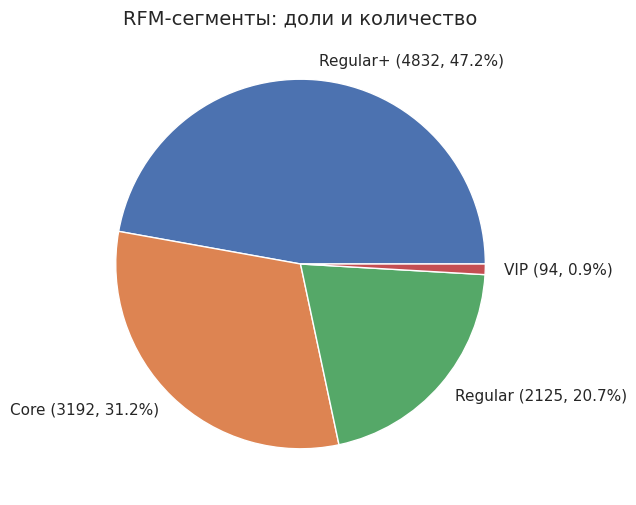

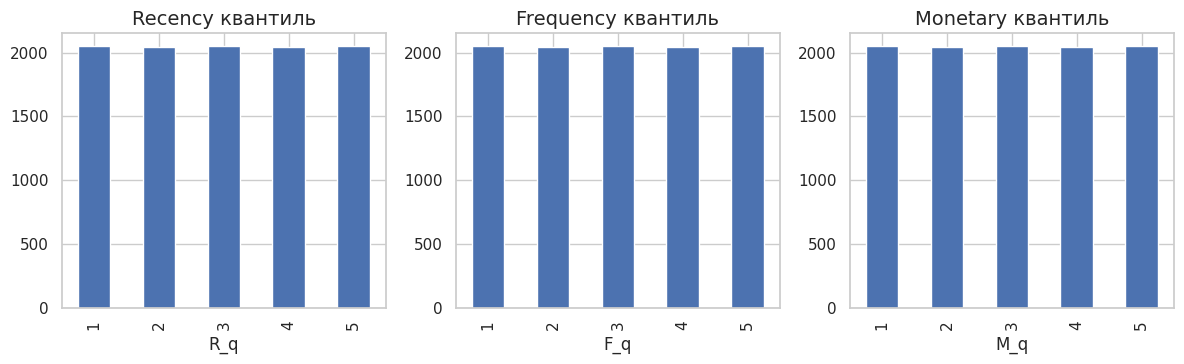

,R,F,M,R_q,F_q,M_q,Segment_RFM
id,,,,,,,
1181145,2.0,23.0,460.0,2,5,5,Core
1021825,0.0,21.0,452.0,5,5,5,VIP
1159545,10.0,16.0,450.0,1,5,5,Core
1037585,23.0,15.0,441.0,1,5,5,Core
1161545,0.0,20.0,434.0,3,5,5,VIP
1031185,7.0,16.0,432.0,2,5,5,Core
1015425,0.0,14.0,426.0,5,5,5,VIP
1026845,26.0,14.0,416.0,1,5,5,Core
1052905,1.0,16.0,412.0,2,5,5,Core


In [50]:
assert 'data_clients' in globals(), "Нужна витрина data_clients"
ID_COL = 'id'
assert ID_COL in data_clients.columns, f"В витрине нет столбца {ID_COL}"
def _pick_col(cols, src):
    for c in cols:
        if c in src.columns:
            return c
    return None
id_raw = _pick_col(['ID','ClientID','client_id','id'], globals().get('df', data_clients))
if ('df' in globals()) and (id_raw is not None) and ('min_MnthAfterLoan' in df.columns):
    R_series = (df.groupby(id_raw)['min_MnthAfterLoan']
                  .min()
                  .rename('R'))
    R_series.index.name = ID_COL if id_raw == ID_COL else id_raw
else:
    R_series = (data_clients.set_index(ID_COL)['TOTAL_MONEY']
                .rank(ascending=False, method='first')
                .rename('R'))

if ('df' in globals()) and (id_raw is not None) and ('all_credits' in df.columns):
    F_series = df.groupby(id_raw)['all_credits'].max().rename('F')
elif 'N_CHECKS' in data_clients.columns:
    F_series = data_clients.set_index(ID_COL)['N_CHECKS'].rename('F')
else:
    F_series = pd.Series(1, index=data_clients.set_index(ID_COL).index, name='F')

if ('df' in globals()) and (id_raw is not None) and ('sum_of_paym_months' in df.columns):
    M_series = df.groupby(id_raw)['sum_of_paym_months'].sum().rename('M')
elif 'TOTAL_MONEY' in data_clients.columns:
    M_series = data_clients.set_index(ID_COL)['TOTAL_MONEY'].rename('M')
else:

    M_series = data_clients.set_index(ID_COL)[_pick_col(['AVG_CHECK'], data_clients)].rename('M')

rfm = (pd.DataFrame(index=data_clients.set_index(ID_COL).index)
         .join([R_series, F_series, M_series], how='left')
         .fillna(0))
rfm['R_q'] = pd.qcut(rfm['R'].rank(method='first'), 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_q'] = pd.qcut(rfm['F'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_q'] = pd.qcut(rfm['M'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

def rfm_bucket(row):
    score = int(row.R_q + row.F_q + row.M_q)
    if score >= 13:        return 'VIP'
    if 10 <= score <= 12:  return 'Core'
    if 8  <= score <= 9:   return 'Regular+'
    if 6  <= score <= 7:   return 'Regular'
    return 'Churn risk'

rfm['Segment_RFM'] = rfm.apply(rfm_bucket, axis=1)

counts = rfm['Segment_RFM'].value_counts()
share_max = counts.max() / counts.sum()
print("Доли RFM:", (counts / counts.sum()).round(3).to_dict())
assert share_max <= 0.5 + 1e-9, "В RFM один сегмент >50% — ослабь границы (например, смести пороги score)"

plt.figure(figsize=(6,6))
labels = [f"{k} ({n}, {n/rfm.shape[0]:.1%})" for k,n in zip(counts.index, counts.values)]
plt.pie(counts.values, labels=labels)
plt.title('RFM-сегменты: доли и количество')
plt.show()

fig, axes = plt.subplots(1,3, figsize=(12,3.8))
(rfm['R_q'].value_counts().sort_index()
    .plot(kind='bar', ax=axes[0], title='Recency квантиль'))
(rfm['F_q'].value_counts().sort_index()
    .plot(kind='bar', ax=axes[1], title='Frequency квантиль'))
(rfm['M_q'].value_counts().sort_index()
    .plot(kind='bar', ax=axes[2], title='Monetary квантиль'))
plt.tight_layout(); plt.show()

top10M = rfm.sort_values('M', ascending=False).head(10)
display(top10M[['R','F','M','R_q','F_q','M_q','Segment_RFM']])


### Профили клиентов по RFM-сегментации

**VIP (RFM ≥ 13)** — **0.9 %** клиентов  
- Самая прибыльная, но небольшая группа.  
- Недавно активны, совершают частые и крупные транзакции.  
- Средний чек и сумма по всем операциям — максимальные среди сегментов.  
- *Рекомендации:* премиум-обслуживание, персональные предложения, приоритетная поддержка.

**Core (RFM 10–12)** — **≈31 %**  
- Основная стабильная аудитория банка.  
- Регулярно совершают операции со средним объёмом и частотой.  
- Дают устойчивый денежный поток.  
- *Рекомендации:* программы лояльности, апселл-продукты (кредитные карты, инвестиции), уведомления о выгодных ставках.

**Regular+ (RFM 8–9)** — **≈47 %**  
- Самая крупная доля клиентской базы.  
- Используют услуги банка периодически, но без высокой интенсивности.  
- Средний чек и частота немного ниже Core.  
- *Рекомендации:* стимулировать активность — бонусы за повторные операции, персональные напоминания.

**Regular (RFM 6–7)** — **≈20 %**  
- Клиенты с невысокой активностью и суммами операций.  
- Вероятно, используют банк для отдельных целей (оплаты, редкие переводы).  
- *Рекомендации:* предложить кросс-продукты (депозиты, карты с кешбэком), таргетировать на повышение частоты операций.

**Churn risk (RFM ≤ 5)** — *почти отсутствует* (менее 1 %)  
- Клиенты с минимальной активностью или уже не взаимодействующие.  
- *Рекомендации:* реактивационные кампании, персональные скидки, напоминания о неиспользуемых продуктах.


# Market Basket Analysis на one-hot витрине

In [54]:
import os, io, contextlib, warnings
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

from mlxtend.frequent_patterns import apriori, association_rules

PREFIXES = ['CREDIT_PURPOSE__','INCOME_BASE_TYPE__','SEX__','EDUCATION__',
    'EMPL_TYPE__','EMPL_SIZE__','EMPL_PROPERTY__','EMPL_FORM__','FAMILY_STATUS__',
    'TN__','TK__','Source__','PaymentType__','Region__']
MIN_ITEMS_PER_ROW = 2
MIN_CONF = 0.35
MIN_LIFT = 1.2
MAX_RULE_LEN = 4
ABS_SUPPORT_OVERALL = 30
ABS_SUPPORT_CLUSTER_MIN = 10

выбираем one-hot столбцы и отбрасываем пустые

In [55]:
one_hot_cols = [c for c in data_clients.columns if any(c.startswith(p) for p in PREFIXES)]
if not one_hot_cols:
    print("[MBA] Нет one-hot = пропуск.")
    rules_all, all_rules = pd.DataFrame(), {}
else:
    B_all = (data_clients[one_hot_cols].fillna(0) > 0).astype("int8")
    non_empty_cols = [c for c in B_all.columns if B_all[c].sum() > 0]
    B_all = B_all[non_empty_cols]
    B_all = B_all[(B_all > 0).sum(axis=1) >= MIN_ITEMS_PER_ROW].copy()
    n_all = len(B_all)
    if n_all == 0:
        print("[MBA] После фильтрации не осталось строк для анализа")
        rules_all, all_rules = pd.DataFrame(), {}
    else:
        ms_all = 0.03 if n_all >= 5000 else (0.02 if n_all >= 1000 else 0.01)
        def _format_rules(df, topn=15):
            if df is None or df.empty:
                return pd.DataFrame(columns=['antecedents','consequents','support_%','support_abs','confidence_%','lift'])
            r = df.copy()
            r['antecedents'] = r['antecedents'].apply(lambda s: ', '.join(sorted(list(s))))
            r['consequents'] = r['consequents'].apply(lambda s: ', '.join(sorted(list(s))))
            r = r[['antecedents','consequents','support','confidence','lift']].copy()
            r['support_abs'] = (r['support'] * n_all).round().astype(int)
            r = r.sort_values(['lift','confidence','support'], ascending=False).head(topn)
            r['support_%'] = (r.pop('support')*100).round(1)
            r['confidence_%'] = (r.pop('confidence')*100).round(1)
            r['lift'] = r['lift'].round(2)
            cols = ['antecedents','consequents','support_%','support_abs','confidence_%','lift']
            return r[cols]
        def _run_mba(basket, min_support, min_conf=MIN_CONF, min_lift=MIN_LIFT):
            """Запуск Apriori + правила с фильтрацией по lift."""
            if basket.empty:
                return pd.DataFrame(), pd.DataFrame()
            with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()):
                fi = apriori(basket, min_support=min_support, use_colnames=True)
                if fi.empty:
                    return fi, pd.DataFrame()
                rules = association_rules(fi, metric="confidence", min_threshold=min_conf)
            if rules.empty:
                return fi, rules
            rules = rules[rules['lift'] >= min_lift].sort_values('lift', ascending=False)
            return fi, rules

        def postfilter_rules(rules, n_samples, min_support_abs=ABS_SUPPORT_OVERALL, max_len=MAX_RULE_LEN):
            """Добор фильтров: абсолютная поддержка, ограничение длины, удаление дублей."""
            if rules is None or rules.empty:
                return rules
            r = rules.copy()
            r['support_abs'] = (r['support'] * n_samples).round().astype(int)
            r = r[r['support_abs'] >= min_support_abs]
            r = r[(r['antecedents'].apply(len) + r['consequents'].apply(len)) <= max_len]
            r = r.drop_duplicates(subset=['antecedents','consequents'])
            return r.sort_values(['lift','confidence','support'], ascending=False)
        _, rules_all_raw = _run_mba(B_all, min_support=ms_all)
        rules_all = postfilter_rules(rules_all_raw, n_samples=n_all,
                                     min_support_abs=ABS_SUPPORT_OVERALL, max_len=MAX_RULE_LEN)
        print(f"[MBA] Общая выборка: транзакций={n_all:,}, правил={len(rules_all):,}")
        display(_format_rules(rules_all, topn=15))
        all_rules = {}
        if "labels_km_df" in globals() and {'id','Labels_KM'}.issubset(labels_km_df.columns):
            DC = data_clients.set_index('id')
            idx = data_clients[['id']].merge(labels_km_df[['id','Labels_KM']], on='id', how='left')
            uniq = sorted(idx['Labels_KM'].dropna().unique().tolist())

            for cid in uniq:
                ids = idx.loc[idx['Labels_KM'] == cid, 'id'].values
                Bc = (DC.loc[DC.index.isin(ids), non_empty_cols].fillna(0) > 0).astype("int8")
                Bc = Bc[(Bc > 0).sum(axis=1) >= MIN_ITEMS_PER_ROW]
                n_c = len(Bc)
                if n_c == 0:
                    all_rules[int(cid)] = pd.DataFrame()
                    print(f"[MBA] Кластер {int(cid)}: транзакций=0, правил=0")
                    continue
                ms_c = 0.03 if n_c >= 5000 else (0.02 if n_c >= 1000 else 0.01)
                _, rls_raw = _run_mba(Bc, min_support=ms_c)
                rls = postfilter_rules(
                    rls_raw, n_samples=n_c,
                    min_support_abs=max(ABS_SUPPORT_CLUSTER_MIN, int(0.02 * n_c)),
                    max_len=MAX_RULE_LEN
                )
                all_rules[int(cid)] = rls
                print(f"[MBA] Кластер {int(cid)}: транзакций={n_c:,}, правил={len(rls):,}")

            print("\n[MBA] ТОП-правила по первым трём кластерам:")
            for cid in uniq[:3]:
                print(f"\nКластер {int(cid)}")
                df_show = all_rules.get(int(cid), pd.DataFrame())
                df_show = df_show.copy()
                n_c = len(DC.loc[DC.index.isin(idx.loc[idx['Labels_KM']==cid, 'id']), :])
                def _fmt_local(df_rules, topn=10, n_samples=n_c):
                    if df_rules is None or df_rules.empty:
                        return pd.DataFrame({'msg':['Правила не найдены']})
                    r = df_rules.copy()
                    r['antecedents'] = r['antecedents'].apply(lambda s: ', '.join(sorted(list(s))))
                    r['consequents'] = r['consequents'].apply(lambda s: ', '.join(sorted(list(s))))
                    r = r[['antecedents','consequents','support','confidence','lift']].copy()
                    r['support_abs'] = (r['support'] * n_samples).round().astype(int)
                    r = r.sort_values(['lift','confidence','support'], ascending=False).head(topn)
                    r['support_%'] = (r.pop('support')*100).round(1)
                    r['confidence_%'] = (r.pop('confidence')*100).round(1)
                    r['lift'] = r['lift'].round(2)
                    return r[['antecedents','consequents','support_%','support_abs','confidence_%','lift']]
                display(_fmt_local(df_show, topn=10))
        else:
            print("[MBA] labels_km_df не найден или без нужных колонок — кластерная MBA пропущена.")

[MBA] Общая выборка: транзакций=10,243, правил=526


,antecedents,consequents,support_%,support_abs,confidence_%,lift
1321,"EMPL_PROPERTY__Торговля, INCOME_BASE_TYPE__Пос...","EMPL_FORM__ООО, EMPL_SIZE__>250",5.8,590,78.2,4.04
712,"EMPL_FORM__ООО, INCOME_BASE_TYPE__Форма банка ...",EMPL_SIZE__< 50,3.9,395,53.2,3.85
121,EMPL_TYPE__менеджер высшего звена,EMPL_SIZE__< 50,3.5,355,52.2,3.78
923,"EMPL_PROPERTY__Торговля, INCOME_BASE_TYPE__Пос...","EMPL_FORM__ООО, SEX__женский",3.7,376,49.9,3.70
935,"EMPL_PROPERTY__Торговля, EMPL_TYPE__специалист","EMPL_FORM__ООО, SEX__женский",3.2,327,47.7,3.54
1038,"EDUCATION__среднее-специальное, EMPL_SIZE__>25...",EMPL_TYPE__рабочий,3.0,311,44.4,3.50
709,"EMPL_PROPERTY__Торговля, INCOME_BASE_TYPE__Фор...",EMPL_SIZE__< 50,3.2,323,48.4,3.50
1320,"EMPL_PROPERTY__Торговля, EMPL_SIZE__>250","EMPL_FORM__ООО, INCOME_BASE_TYPE__Поступление ...",5.8,590,36.4,3.42
1322,"EMPL_FORM__ООО, INCOME_BASE_TYPE__Поступление ...","EMPL_PROPERTY__Торговля, EMPL_SIZE__>250",5.8,590,54.2,3.42
1126,"EMPL_SIZE__>250, EMPL_TYPE__рабочий","EMPL_PROPERTY__Производство, SEX__мужской",4.1,416,40.9,3.38


[MBA] Кластер 0: транзакций=2,991, правил=722
[MBA] Кластер 1: транзакций=994, правил=2,038
[MBA] Кластер 2: транзакций=3,989, правил=789
[MBA] Кластер 3: транзакций=335, правил=1,691
[MBA] Кластер 4: транзакций=1,626, правил=1,485

[MBA] ТОП-правила по первым трём кластерам:

Кластер 0


,antecedents,consequents,support_%,support_abs,confidence_%,lift
2366,"EMPL_PROPERTY__Торговля, INCOME_BASE_TYPE__Пос...","EMPL_FORM__ООО, EMPL_SIZE__>250",3.1,93,79.5,11.11
2367,"EMPL_FORM__ООО, EMPL_SIZE__>250","EMPL_PROPERTY__Торговля, INCOME_BASE_TYPE__Пос...",3.1,93,43.5,11.11
516,EMPL_TYPE__другое,"EMPL_PROPERTY__Финансы, SEX__женский",2.3,68,100.0,10.68
146,EMPL_TYPE__другое,EMPL_PROPERTY__Финансы,2.3,68,100.0,10.68
515,"EMPL_TYPE__другое, SEX__женский",EMPL_PROPERTY__Финансы,2.3,68,100.0,10.68
2364,"EMPL_PROPERTY__Торговля, EMPL_SIZE__>250","EMPL_FORM__ООО, INCOME_BASE_TYPE__Поступление ...",3.1,93,49.2,9.68
2368,"EMPL_FORM__ООО, INCOME_BASE_TYPE__Поступление ...","EMPL_PROPERTY__Торговля, EMPL_SIZE__>250",3.1,93,61.2,9.68
2191,"CREDIT_PURPOSE__Ремонт, EMPL_FORM__ООО","EDUCATION__высшее, EMPL_PROPERTY__Торговля",2.4,72,49.0,9.51
2190,"EDUCATION__высшее, EMPL_PROPERTY__Торговля","CREDIT_PURPOSE__Ремонт, EMPL_FORM__ООО",2.4,72,46.8,9.51
2187,"CREDIT_PURPOSE__Ремонт, EDUCATION__высшее, EMP...",EMPL_PROPERTY__Торговля,2.4,72,77.4,9.45



Кластер 1


,antecedents,consequents,support_%,support_abs,confidence_%,lift
5431,"EMPL_TYPE__менеджер высшего звена, INCOME_BASE...","EMPL_SIZE__< 50, SEX__мужской",3.7,37,62.7,5.83
4492,"EDUCATION__высшее, EMPL_SIZE__< 50, SEX__мужской",EMPL_TYPE__менеджер высшего звена,3.5,35,50.7,5.60
4496,EMPL_TYPE__менеджер высшего звена,"EDUCATION__высшее, EMPL_SIZE__< 50, SEX__мужской",3.5,35,38.9,5.60
4716,"EDUCATION__среднее-специальное, EMPL_SIZE__>25...",EMPL_TYPE__рабочий,2.1,21,43.8,5.30
5429,"EMPL_SIZE__< 50, INCOME_BASE_TYPE__Форма банка...",EMPL_TYPE__менеджер высшего звена,3.7,37,47.4,5.24
5433,EMPL_TYPE__менеджер высшего звена,"EMPL_SIZE__< 50, INCOME_BASE_TYPE__Форма банка...",3.7,37,41.1,5.24
6936,EMPL_TYPE__менеджер высшего звена,"EDUCATION__высшее, EMPL_SIZE__< 50, INCOME_BAS...",3.5,35,38.9,5.02
6932,"EDUCATION__высшее, EMPL_SIZE__< 50, INCOME_BAS...",EMPL_TYPE__менеджер высшего звена,3.5,35,45.5,5.02
5430,"EMPL_TYPE__менеджер высшего звена, SEX__мужской","EMPL_SIZE__< 50, INCOME_BASE_TYPE__Форма банка...",3.7,37,61.7,4.94
4495,"EDUCATION__высшее, EMPL_TYPE__менеджер высшего...","EMPL_SIZE__< 50, SEX__мужской",3.5,35,53.0,4.93



Кластер 2


,antecedents,consequents,support_%,support_abs,confidence_%,lift
1674,"EMPL_FORM__ООО, EMPL_SIZE__>250, SEX__мужской",EMPL_PROPERTY__Торговля,2.2,89,55.3,15.53
855,"EMPL_FORM__ООО, EMPL_SIZE__>250",EMPL_PROPERTY__Торговля,2.2,89,55.3,15.53
1678,"EMPL_FORM__ООО, EMPL_SIZE__>250","EMPL_PROPERTY__Торговля, SEX__мужской",2.2,89,55.3,15.53
1680,EMPL_PROPERTY__Торговля,"EMPL_FORM__ООО, EMPL_SIZE__>250, SEX__мужской",2.2,89,62.7,15.53
1676,"EMPL_PROPERTY__Торговля, SEX__мужской","EMPL_FORM__ООО, EMPL_SIZE__>250",2.2,89,62.7,15.53
856,EMPL_PROPERTY__Торговля,"EMPL_FORM__ООО, EMPL_SIZE__>250",2.2,89,62.7,15.53
1671,"EMPL_PROPERTY__Торговля, EMPL_SIZE__>250, SEX_...",EMPL_FORM__ООО,2.2,89,79.5,15.31
853,"EMPL_PROPERTY__Торговля, EMPL_SIZE__>250",EMPL_FORM__ООО,2.2,89,79.5,15.31
1675,"EMPL_PROPERTY__Торговля, EMPL_SIZE__>250","EMPL_FORM__ООО, SEX__мужской",2.2,89,79.5,15.31
1681,EMPL_FORM__ООО,"EMPL_PROPERTY__Торговля, EMPL_SIZE__>250, SEX_...",2.2,89,43.0,15.31


### Интерпретация результатов Market Basket Analysis
Анализ ассоциативных правил выявил закономерности между социально-профессиональными характеристиками клиентов.  
Наиболее сильная связь (lift > 3) наблюдается между:
- работой в торговле и занятостью в крупных ООО (численность > 250 чел.),
- использованием справки формы банка и принадлежностью к малому бизнесу,
- женским полом, торговой сферой и целью кредита «ремонт».

Эти паттерны позволяют сегментировать продуктовые предложения:
- для **крупных торговых компаний** — ипотека и автокредитование;
- для **малого бизнеса** — лояльные условия кредитных карт;
- для **производственного сегмента** — программы страхования.
